In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# First, I have to laod different modules that I use for analyzing the data and for plotting:
import sys, os, collections
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt; plt.rcdefaults()
import re
#from matplotlib.pyplot import figure
from collections import Counter

# Second, I have to load the Text Fabric app
from tf.fabric import Fabric
from tf.app import use

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
pd.set_option('display.max_rows', 40)

In [6]:
%time
N1904 = use ("CenterBLC/N1904", version="1.0.0", mod="CenterBLC/N1904/BOLcomplement/tf/", hoist=globals())
gntF, gntL, gntT, gntS = N1904.api.F, N1904.api.L, N1904.api.T, N1904.api.S

CPU times: user 1 μs, sys: 1 μs, total: 2 μs
Wall time: 3.1 μs


**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,27,5102.93,100
chapter,260,529.92,100
verse,7944,17.34,100
sentence,8011,17.20,100
group,8945,7.01,46
clause,42506,8.36,258
wg,106868,6.88,533
phrase,69007,1.90,95
subphrase,116178,1.60,135
word,137779,1.00,100


Display is setup for viewtype [syntax-view](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/syntax-view.md#start)

See [here](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/viewtypes.md#start) for more information on viewtypes

## A Distributional Synoptic Perspective on the so-called “Historical Present” tense of NT Greek

### Data Creation

In the query below we are collecting from each of the four gosples only those verbal forms that are in present tense and are shared accross the four gospels in the same synoptic text passage.

In [8]:
SynopticTense1 = '''
b1:verse book=Matthew chapter* verse*
     w1:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*
b2:verse book=Mark chapter* verse*
     w2:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*
b3:verse book=Luke chapter* verse*
     w3:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*
b4:verse book=John chapter* verse*
     w4:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*

w1 .AlandSynopEvent=AlandSynopEvent. w2
w2 .AlandSynopEvent=AlandSynopEvent. w3
w3 .AlandSynopEvent=AlandSynopEvent. w4

w1 .bol_lemma=bol_lemma. w2
w2 .bol_lemma=bol_lemma. w3
w3 .bol_lemma=bol_lemma. w4




'''
SynopticTense1 = N1904.search(SynopticTense1)
N1904.table(SynopticTense1, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)

  2.24s 9879 results


In [9]:
MatMar = '''
b1:verse book=Matthew chapter* verse*
     w1:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*
b2:verse book=Mark chapter* verse*
     w2:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*

w1 .AlandSynopEvent=AlandSynopEvent. w2

'''
MatMar = N1904.search(MatMar)
N1904.table(MatMar, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  1.05s 55570 results


We are now collecting for each book all words with its Synoptic information.

In [10]:
MT = '''
verse book=Matthew chapter* verse*
     word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num* bol_mood* lemmatranslit*

'''
MT = N1904.search(MT)
N1904.table(MT, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.26s 3636 results


In [11]:
MK = '''
verse book=Mark chapter* verse*
     word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num* bol_mood* lemmatranslit*

'''
MK = N1904.search(MK)
N1904.table(MK, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.26s 2405 results


In [12]:
LK = '''
verse book=Luke chapter* verse*
     word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num* bol_mood* lemmatranslit*

'''
LK = N1904.search(LK)
N1904.table(LK, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.26s 3932 results


In [13]:
JN = '''
verse book=John chapter* verse*
     word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num* bol_mood* lemmatranslit*

'''
JN = N1904.search(JN)
N1904.table(JN, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.26s 3111 results


In [14]:
N1904.export(MT+MK+LK+JN, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research', toFile='SynopticTense20240730.tsv')

### Data Loading

In [15]:
words=pd.read_excel('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research/SynopticTense20240730.xlsx')
pd.set_option('display.max_columns', 50)
words.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,indicative,aorist,active,Pred,gennao,verb
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,indicative,aorist,active,Pred,gennao,verb
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,indicative,aorist,active,Pred,gennao,verb
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,indicative,aorist,active,Pred,gennao,verb
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,indicative,aorist,active,Pred,gennao,verb


Lets combine Aorist with 2nd Aorist tense.

In [16]:
def tensecombi(row):
    if re.search('^.*aorist*', str(row)):
        return 'aorist_combined'    
    if re.search('^.*present*', str(row)):
        return 'present' 
    if re.search('^.*future*', str(row)):
        return 'future_combined' 
    if re.search('^perfect', str(row)):
        return 'perfect_combined' 
    if re.search('^.*_perfect', str(row)):
        return 'perfect_combined' 
    if re.search('^.*pluperfect*', str(row)):
        return 'plusperfect_combined' 
    if re.search('^imperfect', str(row)):
        return 'imperfect'    
 

    else:
        return ''

In [17]:
words['combitense']=words['bol_tense2'].apply(tensecombi)
words.head(10)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,indicative,aorist,active,Pred,gennao,verb,aorist_combined
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,indicative,aorist,active,Pred,gennao,verb,aorist_combined
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,indicative,aorist,active,Pred,gennao,verb,aorist_combined
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,indicative,aorist,active,Pred,gennao,verb,aorist_combined
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,indicative,aorist,active,Pred,gennao,verb,aorist_combined
5,6,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,45,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,45,indicative,aorist,active,Pred,gennao,verb,aorist_combined
6,7,Matthew,1,4,382717,verse,"Ἀρὰμ δὲ ἐγέννησεν τὸν Ἀμιναδάβ, Ἀμιναδὰβ δὲ ἐγ...",Matthew,1,4,50,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,50,indicative,aorist,active,Pred,gennao,verb,aorist_combined
7,8,Matthew,1,4,382717,verse,"Ἀρὰμ δὲ ἐγέννησεν τὸν Ἀμιναδάβ, Ἀμιναδὰβ δὲ ἐγ...",Matthew,1,4,55,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,55,indicative,aorist,active,Pred,gennao,verb,aorist_combined
8,9,Matthew,1,4,382717,verse,"Ἀρὰμ δὲ ἐγέννησεν τὸν Ἀμιναδάβ, Ἀμιναδὰβ δὲ ἐγ...",Matthew,1,4,60,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,60,indicative,aorist,active,Pred,gennao,verb,aorist_combined
9,10,Matthew,1,5,382718,verse,"Σαλμὼν δὲ ἐγέννησεν τὸν Βόες ἐκ τῆς Ῥαχάβ, Βόε...",Matthew,1,5,65,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,65,indicative,aorist,active,Pred,gennao,verb,aorist_combined


#### Selecting Syntopic Sections only
We are now filtering out only Synoptic materials.

In [18]:
SynopSelection=words[(words["AlandSynopNo2"] > 1)]
SynopSelection.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,indicative,aorist,active,Pred,gennao,verb,aorist_combined
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,indicative,aorist,active,Pred,gennao,verb,aorist_combined
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,indicative,aorist,active,Pred,gennao,verb,aorist_combined
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,indicative,aorist,active,Pred,gennao,verb,aorist_combined
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,indicative,aorist,active,Pred,gennao,verb,aorist_combined


##### Matthew

In [19]:
MTSynopSelection=SynopSelection[(SynopSelection["book1"].str.contains('^Matt'))
                                &
                                (SynopSelection["bol_mood2"].str.contains('^indicat'))
                               ]
MTSynopSelection.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,indicative,aorist,active,Pred,gennao,verb,aorist_combined
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,indicative,aorist,active,Pred,gennao,verb,aorist_combined
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,indicative,aorist,active,Pred,gennao,verb,aorist_combined
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,indicative,aorist,active,Pred,gennao,verb,aorist_combined
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,indicative,aorist,active,Pred,gennao,verb,aorist_combined


In [20]:
MTSynopSelection['combitense'].value_counts().to_frame('count').join(MTSynopSelection.combitense.value_counts(normalize=True).to_frame('%'))

,count,%
combitense,,
aorist_combined,923,0.474550
present,558,0.286889
future_combined,300,0.154242
imperfect,104,0.053470
perfect_combined,52,0.026735
plusperfect_combined,8,0.004113


##### Mark

In [21]:
MKSynopSelection=SynopSelection[(SynopSelection["book1"].str.contains('^Mark'))
                                &
                                (SynopSelection["bol_mood2"].str.contains('^indicat'))
                               ]
MKSynopSelection.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
3636,3637,Mark,1,2,383783,verse,Καθὼς γέγραπται ἐν τῷ Ἠσαΐᾳ τῷ προφήτῃ Ἰδοὺ ἀπ...,Mark,1,2,18308,word,γέγραπται,Preparation,John the Baptist,13.0,γράφω,18308,indicative,perfect,middle_or_passive,Pred,grapho,verb,perfect_combined
3637,3638,Mark,1,2,383783,verse,Καθὼς γέγραπται ἐν τῷ Ἠσαΐᾳ τῷ προφήτῃ Ἰδοὺ ἀπ...,Mark,1,2,18315,word,ἀποστέλλω,Preparation,John the Baptist,13.0,ἀποστέλλω,18315,indicative,present,active,Pred,apostello,verb,present
3638,3639,Mark,1,2,383783,verse,Καθὼς γέγραπται ἐν τῷ Ἠσαΐᾳ τῷ προφήτῃ Ἰδοὺ ἀπ...,Mark,1,2,18323,word,κατασκευάσει,Preparation,John the Baptist,13.0,κατασκευάζω,18323,indicative,future,active,Pred,kataskeuazo,verb,future_combined
3642,3643,Mark,1,4,383785,verse,ἐγένετο Ἰωάνης ὁ βαπτίζων ἐν τῇ ἐρήμῳ κηρύσσων...,Mark,1,4,18341,word,ἐγένετο,Preparation,John the Baptist,13.0,γίνομαι,18341,indicative,second_aorist,middle_deponent,Pred,ginomai,verb,aorist_combined
3645,3646,Mark,1,5,383786,verse,καὶ ἐξεπορεύετο πρὸς αὐτὸν πᾶσα ἡ Ἰουδαία χώρα...,Mark,1,5,18355,word,ἐξεπορεύετο,Preparation,John the Baptist,13.0,ἐκπορεύομαι,18355,indicative,imperfect,middle_or_passive_deponent,Pred,ekporeuomai,verb,imperfect


In [22]:
MKSynopSelection['combitense'].value_counts().to_frame('count').join(MKSynopSelection.combitense.value_counts(normalize=True).to_frame('%'))

,count,%
combitense,,
aorist_combined,526,0.397281
present,404,0.305136
imperfect,236,0.178248
future_combined,105,0.079305
perfect_combined,45,0.033988
plusperfect_combined,8,0.006042


##### Luke

In [23]:
LKSynopSelection=SynopSelection[(SynopSelection["book1"].str.contains('^Lu'))
                                &
                                (SynopSelection["bol_mood2"].str.contains('^indicat'))
                               ]
LKSynopSelection.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
6050,6051,Luke,1,5,384460,verse,Ἐγένετο ἐν ταῖς ἡμέραις Ἠρῴδου βασιλέως τῆς Ἰο...,Luke,1,5,29619,word,Ἐγένετο,Birth and Childhood,The Promise of the Birth of John the Baptist,2.0,γίνομαι,29619,indicative,second_aorist,middle_deponent,Pred,ginomai,verb,aorist_combined
6052,6053,Luke,1,8,384463,verse,Ἐγένετο δὲ ἐν τῷ ἱερατεύειν αὐτὸν ἐν τῇ τάξει ...,Luke,1,8,29681,word,Ἐγένετο,Birth and Childhood,The Promise of the Birth of John the Baptist,2.0,γίνομαι,29681,indicative,second_aorist,middle_deponent,Pred,ginomai,verb,aorist_combined
6054,6055,Luke,1,9,384464,verse,κατὰ τὸ ἔθος τῆς ἱερατείας ἔλαχε τοῦ θυμιᾶσαι ...,Luke,1,9,29701,word,ἔλαχε,Birth and Childhood,The Promise of the Birth of John the Baptist,2.0,λαγχάνω,29701,indicative,second_aorist,active,Pred,lagkhano,verb,aorist_combined
6057,6058,Luke,1,11,384466,verse,ὤφθη δὲ αὐτῷ ἄγγελος Κυρίου ἑστὼς ἐκ δεξιῶν το...,Luke,1,11,29723,word,ὤφθη,Birth and Childhood,The Promise of the Birth of John the Baptist,2.0,ὁράω,29723,indicative,aorist,passive,Pred,orao,verb,aorist_combined
6059,6060,Luke,1,12,384467,verse,"καὶ ἐταράχθη Ζαχαρίας ἰδών, καὶ φόβος ἐπέπεσεν...",Luke,1,12,29736,word,ἐταράχθη,Birth and Childhood,The Promise of the Birth of John the Baptist,2.0,ταράσσω,29736,indicative,aorist,passive,Pred,tarasso,verb,aorist_combined


In [24]:
LKSynopSelection['combitense'].value_counts().to_frame('count').join(LKSynopSelection.combitense.value_counts(normalize=True).to_frame('%'))

,count,%
combitense,,
aorist_combined,1041,0.499281
present,447,0.214388
future_combined,262,0.125659
imperfect,260,0.124700
perfect_combined,59,0.028297
plusperfect_combined,16,0.007674


##### John

In [25]:
JNSynopSelection=SynopSelection[(SynopSelection["book1"].str.contains('^J'))
                                &
                                (SynopSelection["bol_mood2"].str.contains('^indicat'))
                               ]
JNSynopSelection.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
10005,10006,John,1,19,385623,verse,Καὶ αὕτη ἐστὶν ἡ μαρτυρία τοῦ Ἰωάνου ὅτε ἀπέστ...,John,1,19,49293,word,ἀπέστειλαν,Preparation,John the Baptist,13.0,ἀποστέλλω,49293,indicative,aorist,active,Pred,apostello,verb,aorist_combined
10007,10008,John,1,20,385624,verse,"καὶ ὡμολόγησεν καὶ οὐκ ἠρνήσατο, καὶ ὡμολόγησε...",John,1,20,49310,word,ὡμολόγησεν,Preparation,John the Baptist,13.0,ὁμολογέω,49310,indicative,aorist,active,Pred,omologeo,verb,aorist_combined
10008,10009,John,1,20,385624,verse,"καὶ ὡμολόγησεν καὶ οὐκ ἠρνήσατο, καὶ ὡμολόγησε...",John,1,20,49313,word,"ἠρνήσατο,",Preparation,John the Baptist,13.0,ἀρνέομαι,49313,indicative,aorist,middle_deponent,Pred,arneomai,verb,aorist_combined
10009,10010,John,1,20,385624,verse,"καὶ ὡμολόγησεν καὶ οὐκ ἠρνήσατο, καὶ ὡμολόγησε...",John,1,20,49315,word,ὡμολόγησεν,Preparation,John the Baptist,13.0,ὁμολογέω,49315,indicative,aorist,active,Pred,omologeo,verb,aorist_combined
10010,10011,John,1,21,385625,verse,καὶ ἠρώτησαν αὐτόν Τί οὖν; σὺ Ἠλείας εἶ; καὶ λ...,John,1,21,49323,word,ἠρώτησαν,Preparation,John the Baptist,13.0,ἐρωτάω,49323,indicative,aorist,active,Pred,erotao,verb,aorist_combined


In [26]:
JNSynopSelection['combitense'].value_counts().to_frame('count').join(JNSynopSelection.combitense.value_counts(normalize=True).to_frame('%'))

,count,%
combitense,,
aorist_combined,802,0.382816
present,736,0.351313
perfect_combined,192,0.091647
imperfect,176,0.084010
future_combined,153,0.073031
plusperfect_combined,36,0.017184


### *HPT in Syoptic Healing (no longer used)

In [27]:
SynopSelection.head(5)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,indicative,aorist,active,Pred,gennao,verb,aorist_combined
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,indicative,aorist,active,Pred,gennao,verb,aorist_combined
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,indicative,aorist,active,Pred,gennao,verb,aorist_combined
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,indicative,aorist,active,Pred,gennao,verb,aorist_combined
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,indicative,aorist,active,Pred,gennao,verb,aorist_combined


In [28]:
Healing=SynopSelection[(SynopSelection["AlandSynopEvent2"].str.contains('Heal'))
                                &
                                (SynopSelection["bol_mood2"].str.contains('^indicat'))
                               ]
Healing.head(10)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
718,719,Matthew,8,14,382928,verse,Καὶ ἐλθὼν ὁ Ἰησοῦς εἰς τὴν οἰκίαν Πέτρου εἶδεν...,Matthew,8,14,3874,word,εἶδεν,Jesus’ Ministry in Galilee Continued,The Healing of Peter’s Mother-in-law,37.0,ὁράω,3874,indicative,second_aorist,active,Pred,orao,verb,aorist_combined
719,720,Matthew,8,15,382929,verse,"καὶ ἥψατο τῆς χειρὸς αὐτῆς, καὶ ἀφῆκεν αὐτὴν ὁ...",Matthew,8,15,3882,word,ἥψατο,Jesus’ Ministry in Galilee Continued,The Healing of Peter’s Mother-in-law,37.0,ἅπτω,3882,indicative,aorist,middle_deponent,Pred,apto,verb,aorist_combined
720,721,Matthew,8,15,382929,verse,"καὶ ἥψατο τῆς χειρὸς αὐτῆς, καὶ ἀφῆκεν αὐτὴν ὁ...",Matthew,8,15,3887,word,ἀφῆκεν,Jesus’ Ministry in Galilee Continued,The Healing of Peter’s Mother-in-law,37.0,ἀφίημι,3887,indicative,aorist,active,Pred,aphiemi,verb,aorist_combined
721,722,Matthew,8,15,382929,verse,"καὶ ἥψατο τῆς χειρὸς αὐτῆς, καὶ ἀφῆκεν αὐτὴν ὁ...",Matthew,8,15,3892,word,"ἠγέρθη,",Jesus’ Ministry in Galilee Continued,The Healing of Peter’s Mother-in-law,37.0,ἐγείρω,3892,indicative,aorist,passive,Pred,egeiro,verb,aorist_combined
722,723,Matthew,8,15,382929,verse,"καὶ ἥψατο τῆς χειρὸς αὐτῆς, καὶ ἀφῆκεν αὐτὴν ὁ...",Matthew,8,15,3894,word,διηκόνει,Jesus’ Ministry in Galilee Continued,The Healing of Peter’s Mother-in-law,37.0,διακονέω,3894,indicative,imperfect,active,Pred,diakoneo,verb,imperfect
724,725,Matthew,8,16,382930,verse,Ὀψίας δὲ γενομένης προσήνεγκαν αὐτῷ δαιμονιζομ...,Matthew,8,16,3899,word,προσήνεγκαν,Jesus’ Ministry in Galilee Continued,The Sick Healed at Evening,38.0,προσφέρω,3899,indicative,aorist,active,Pred,prosphero,verb,aorist_combined
726,727,Matthew,8,16,382930,verse,Ὀψίας δὲ γενομένης προσήνεγκαν αὐτῷ δαιμονιζομ...,Matthew,8,16,3904,word,ἐξέβαλεν,Jesus’ Ministry in Galilee Continued,The Sick Healed at Evening,38.0,ἐκβάλλω,3904,indicative,second_aorist,active,Pred,ekballo,verb,aorist_combined
728,729,Matthew,8,16,382930,verse,Ὀψίας δὲ γενομένης προσήνεγκαν αὐτῷ δαιμονιζομ...,Matthew,8,16,3913,word,ἐθεράπευσεν·,Jesus’ Ministry in Galilee Continued,The Sick Healed at Evening,38.0,θεραπεύω,3913,indicative,aorist,active,Pred,therapeuo,verb,aorist_combined
732,733,Matthew,8,17,382931,verse,ὅπως πληρωθῇ τὸ ῥηθὲν διὰ Ἠσαΐου τοῦ προφήτου ...,Matthew,8,17,3927,word,ἔλαβεν,Jesus’ Ministry in Galilee Continued,The Sick Healed at Evening,38.0,λαμβάνω,3927,indicative,second_aorist,active,Pred,lambano,verb,aorist_combined
733,734,Matthew,8,17,382931,verse,ὅπως πληρωθῇ τὸ ῥηθὲν διὰ Ἠσαΐου τοῦ προφήτου ...,Matthew,8,17,3931,word,ἐβάστασεν.,Jesus’ Ministry in Galilee Continued,The Sick Healed at Evening,38.0,βαστάζω,3931,indicative,aorist,active,Pred,bastazo,verb,aorist_combined


In [29]:
Healing.groupby(['combitense','book1']).count().sort_values(['combitense', 'book1', 'R'], ascending=(True, False, True))

R  S1  S2  S3  NODE1  TYPE1  TEXT1  chapter1  \
combitense           book1                                                    
aorist_combined      Matthew  57  57  57  57     57     57     57        57   
                     Mark     67  67  67  67     67     67     67        67   
                     Luke     56  56  56  56     56     56     56        56   
                     John     96  96  96  96     96     96     96        96   
future_combined      Matthew  15  15  15  15     15     15     15        15   
                     Mark      1   1   1   1      1      1      1         1   
                     Luke      3   3   3   3      3      3      3         3   
                     John      9   9   9   9      9      9      9         9   
imperfect            Matthew   4   4   4   4      4      4      4         4   
                     Mark     31  31  31  31     31     31     31        31   
                     Luke     23  23  23  23     23     23     23        23   
                     John     25  25  25  25     25     25     25        25   
perfect_combined     Mark      4   4   4   4      4      4      4         4   
                     Luke      5   5   5   5      5      5      5         5   
                     John     27  27  27  27     27     27     27        27   
plusperfect_combined Mark      1   1   1   1      1      1      1         1   
                     Luke      1   1   1   1      1      1      1         1   
                     John      2   2   2   2      2      2      2         2   
present              Matthew  18  18  18  18     18     18     18        18   
                     Mark     46  46  46  46     46     46     46        46   
                     Luke     19  19  19  19     19     19     19        19   
                     John     78  78  78  78     78     78     78        78   

                              verse1  NODE2  TYPE2  TEXT2  AlandSynopChapter2  \
combitense           book1                                                      
aorist_combined      Matthew      57     57     57     57                  57   
                     Mark         67     67     67     67                  67   
                     Luke         56     56     56     56                  56   
                     John         96     96     96     96                  96   
future_combined      Matthew      15     15     15     15                  15   
                     Mark          1      1      1      1                   1   
                     Luke          3      3      3      3                   3   
                     John          9      9      9      9                   9   
imperfect            Matthew       4      4      4      4                   4   
                     Mark         31     31     31     31                  31   
                     Luke         23     23     23     23                  23   
                     John         25     25     25     25                  25   
perfect_combined     Mark          4      4      4      4                   4   
                     Luke          5      5      5      5                   5   
                     John         27     27     27     27                  27   
plusperfect_combined Mark          1      1      1      1                   1   
                     Luke          1      1      1      1                   1   
                     John          2      2      2      2                   2   
present              Matthew      18     18     18     18                  18   
                     Mark         46     46     46     46                  46   
                     Luke         19     19     19     19                  19   
                     John         78     78     78     78                  78   

                              AlandSynopEvent2  AlandSynopNo2  bol_lemma2  \
combitense           book1                                                  
aorist_combined      Matthew       

### Shared Synoptic Materials in Mark and Matthew

In [30]:
MatMarSynopticMaterials = '''
b1:verse book=Matthew chapter* verse*
     w1:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp* bol_tense* function* bol_voice* bol_monad_num* bol_mood*
b2:verse book=Mark chapter* verse*
     w2:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp* bol_tense* function* bol_voice* bol_monad_num*  bol_mood*

w1 .AlandSynopEvent=AlandSynopEvent. w2

'''
MatMarSynopticMaterials = N1904.search(MatMarSynopticMaterials)
N1904.table(MatMarSynopticMaterials, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


    12s 1243029 results


In [31]:
N1904.export(MatMarSynopticMaterials, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research', toFile='01_MatMarSharedSynopticMaterials_20241101.tsv')

In [32]:
MarMatSynopticMaterials = '''
b1:verse book=Mark chapter* verse*
     w1:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp* bol_tense* function* bol_voice* bol_monad_num* bol_mood*
b2:verse book=Matthew chapter* verse*
     w2:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp* bol_tense* function* bol_voice* bol_monad_num*  bol_mood*

w1 .AlandSynopEvent=AlandSynopEvent. w2

'''
MarMatSynopticMaterials = N1904.search(MarMatSynopticMaterials)
N1904.table(MarMatSynopticMaterials, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)

    12s 1243029 results


In [33]:
N1904.export(MarMatSynopticMaterials, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research', toFile='02_MarMatSharedSynopticMaterials_20241101.tsv')

In [34]:
No1MatMarSharedSynopticMaterials=pd.read_csv('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research/01_MatMarSharedSynopticMaterials_20241101.tsv',delimiter='\t',encoding='utf-16')
pd.set_option('display.max_columns', 50)
No1MatMarSharedSynopticMaterials.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2,NODE3,TYPE3,TEXT3,book3,chapter3,verse3,NODE4,TYPE4,TEXT4,AlandSynopChapter4,AlandSynopEvent4,AlandSynopNo4,bol_lemma4,bol_monad_num4,bol_mood4,bol_tense4,bol_voice4,function4,sp4
0,1,Matthew,1,1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs
1,2,Matthew,1,1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18301,word,τοῦ,Preface,Prologue,1.0,ὁ,18301,NaN,NaN,NaN,NaN,art
2,3,Matthew,1,1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18302,word,εὐαγγελίου,Preface,Prologue,1.0,εὐαγγέλιον,18302,NaN,NaN,NaN,NaN,subs
3,4,Matthew,1,1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18303,word,Ἰησοῦ,Preface,Prologue,1.0,Ἰησοῦς,18303,NaN,NaN,NaN,NaN,subs
4,5,Matthew,1,1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18304,word,Χριστοῦ,Preface,Prologue,1.0,Χριστός,18304,NaN,NaN,NaN,NaN,subs


In [35]:
No1MatMarSharedSynopticMaterials = No1MatMarSharedSynopticMaterials.loc[:, "NODE1":"sp2"]
No1MatMarSharedSynopticMaterials.head()

,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2
0,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs
1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs
2,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs
3,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs
4,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs


In [36]:
No1MatMarSharedSynopticMaterials = No1MatMarSharedSynopticMaterials.drop_duplicates(subset="bol_monad_num2")
No1MatMarSharedSynopticMaterials.head()

,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2
0,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs
7,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,2,word,γενέσεως,Preface,Prologue,1.0,γένεσις,2,NaN,NaN,NaN,NaN,subs
14,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,3,word,Ἰησοῦ,Preface,Prologue,1.0,Ἰησοῦς,3,NaN,NaN,NaN,NaN,subs
21,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,4,word,Χριστοῦ,Preface,Prologue,1.0,Χριστός,4,NaN,NaN,NaN,NaN,subs
28,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,5,word,υἱοῦ,Preface,Prologue,1.0,υἱός,5,NaN,NaN,NaN,NaN,subs


In [37]:
No2MarMatSharedSynopticMaterials=pd.read_csv('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research/02_MarMatSharedSynopticMaterials_20241101.tsv',delimiter='\t',encoding='utf-16')
pd.set_option('display.max_columns', 50)
No2MarMatSharedSynopticMaterials.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2,NODE3,TYPE3,TEXT3,book3,chapter3,verse3,NODE4,TYPE4,TEXT4,AlandSynopChapter4,AlandSynopEvent4,AlandSynopNo4,bol_lemma4,bol_monad_num4,bol_mood4,bol_tense4,bol_voice4,function4,sp4
0,1,Mark,1,1,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs
1,2,Mark,1,1,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,2,word,γενέσεως,Preface,Prologue,1.0,γένεσις,2,NaN,NaN,NaN,NaN,subs
2,3,Mark,1,1,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,3,word,Ἰησοῦ,Preface,Prologue,1.0,Ἰησοῦς,3,NaN,NaN,NaN,NaN,subs
3,4,Mark,1,1,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,4,word,Χριστοῦ,Preface,Prologue,1.0,Χριστός,4,NaN,NaN,NaN,NaN,subs
4,5,Mark,1,1,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,5,word,υἱοῦ,Preface,Prologue,1.0,υἱός,5,NaN,NaN,NaN,NaN,subs


In [38]:
No2MarMatSharedSynopticMaterials = No2MarMatSharedSynopticMaterials.loc[:, "NODE1":"sp2"]
No2MarMatSharedSynopticMaterials.head()

,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2
0,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs
1,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs
2,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs
3,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs
4,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs


In [39]:
No2MarMatSharedSynopticMaterials = No2MarMatSharedSynopticMaterials.drop_duplicates(subset="bol_monad_num2")
No2MarMatSharedSynopticMaterials.head()

,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2
0,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18300,word,Ἀρχὴ,Preface,Prologue,1.0,ἀρχή,18300,NaN,NaN,NaN,NaN,subs
8,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18301,word,τοῦ,Preface,Prologue,1.0,ὁ,18301,NaN,NaN,NaN,NaN,art
16,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18302,word,εὐαγγελίου,Preface,Prologue,1.0,εὐαγγέλιον,18302,NaN,NaN,NaN,NaN,subs
24,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18303,word,Ἰησοῦ,Preface,Prologue,1.0,Ἰησοῦς,18303,NaN,NaN,NaN,NaN,subs
32,383782,verse,Ἀρχὴ τοῦ εὐαγγελίου Ἰησοῦ Χριστοῦ (Υἱοῦ Θεοῦ).,Mark,1,1,18304,word,Χριστοῦ,Preface,Prologue,1.0,Χριστός,18304,NaN,NaN,NaN,NaN,subs


In [40]:
MMSharedSynopticMaterials = pd.concat([No1MatMarSharedSynopticMaterials,No2MarMatSharedSynopticMaterials], ignore_index=True)
MMSharedSynopticMaterials.head()

,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2
0,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs
1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,2,word,γενέσεως,Preface,Prologue,1.0,γένεσις,2,NaN,NaN,NaN,NaN,subs
2,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,3,word,Ἰησοῦ,Preface,Prologue,1.0,Ἰησοῦς,3,NaN,NaN,NaN,NaN,subs
3,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,4,word,Χριστοῦ,Preface,Prologue,1.0,Χριστός,4,NaN,NaN,NaN,NaN,subs
4,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,5,word,υἱοῦ,Preface,Prologue,1.0,υἱός,5,NaN,NaN,NaN,NaN,subs


In [41]:
MMSharedSynopticMaterials['bol_monad_num2'].value_counts().sum()

np.int64(20152)

In [42]:
def tensecombi(row):
    if re.search('^.*aorist*', str(row)):
        return 'aorist_combined'    
    if re.search('^.*present*', str(row)):
        return 'present' 
    if re.search('^.*future*', str(row)):
        return 'future_combined' 
    if re.search('^perfect', str(row)):
        return 'perfect_combined' 
    if re.search('^.*_perfect', str(row)):
        return 'perfect_combined' 
    if re.search('^.*pluperfect*', str(row)):
        return 'plusperfect_combined' 
    if re.search('^imperfect', str(row)):
        return 'imperfect'    
 

    else:
        return ''

In [43]:
MMSharedSynopticMaterials['combitense']=MMSharedSynopticMaterials['bol_tense2'].apply(tensecombi)
MMSharedSynopticMaterials.head(2)

,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,sp2,combitense
0,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,
1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,2,word,γενέσεως,Preface,Prologue,1.0,γένεσις,2,NaN,NaN,NaN,NaN,subs,


In [44]:
MMSharedSynopticMaterials['bol_monad_num2'].value_counts().sum()

np.int64(20152)

In [45]:
MMSharedSynopticMaterials = MMSharedSynopticMaterials.rename(columns={
    'NODE1': 'verse_node', 
    'TEXT1': 'verse_text', 
    'book1': 'book', 
    'chapter1': 'chapter', 
    'verse1': 'verse', 
    'TEXT2': 'word_text', 
    'AlandSynopChapter2': 'AlandSynopChapter', 
    'AlandSynopEvent2': 'AlandSynopEvent', 
    'bol_lemma2': 'bol_lemma', 
    'bol_monad_num2': 'bol_monad_num', 
    'bol_mood2': 'bol_mood', 
    'bol_tense2': 'bol_tense', 
    'bol_voice': 'bol_voice', 
    'function2': 'function', 
    'sp2': 'sp'
})
MMSharedSynopticMaterials.head()

,verse_node,TYPE1,verse_text,book,chapter,verse,NODE2,TYPE2,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
0,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,1,word,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,
1,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,2,word,γενέσεως,Preface,Prologue,1.0,γένεσις,2,NaN,NaN,NaN,NaN,subs,
2,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,3,word,Ἰησοῦ,Preface,Prologue,1.0,Ἰησοῦς,3,NaN,NaN,NaN,NaN,subs,
3,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,4,word,Χριστοῦ,Preface,Prologue,1.0,Χριστός,4,NaN,NaN,NaN,NaN,subs,
4,382714,verse,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,5,word,υἱοῦ,Preface,Prologue,1.0,υἱός,5,NaN,NaN,NaN,NaN,subs,


In [46]:
MMSharedSynopticMaterials = MMSharedSynopticMaterials.drop(columns=['TYPE1', 'NODE2', 'TYPE2'])
MMSharedSynopticMaterials.head()

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
0,382714,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,Βίβλος,Preface,Prologue,1.0,βίβλος,1,NaN,NaN,NaN,NaN,subs,
1,382714,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,γενέσεως,Preface,Prologue,1.0,γένεσις,2,NaN,NaN,NaN,NaN,subs,
2,382714,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,Ἰησοῦ,Preface,Prologue,1.0,Ἰησοῦς,3,NaN,NaN,NaN,NaN,subs,
3,382714,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,Χριστοῦ,Preface,Prologue,1.0,Χριστός,4,NaN,NaN,NaN,NaN,subs,
4,382714,Βίβλος γενέσεως Ἰησοῦ Χριστοῦ υἱοῦ Δαυεὶδ υἱοῦ...,Matthew,1,1,υἱοῦ,Preface,Prologue,1.0,υἱός,5,NaN,NaN,NaN,NaN,subs,


#### Canonical Dataset for Shared Synoptic Material between Matthew and Mark

In [47]:
MMSharedSynopticMaterials['bol_monad_num'].value_counts().sum()

np.int64(20152)

In [48]:
MMSharedSynopticMaterials.to_excel("/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research/MatMarSynopticMaterials20241101.xlsx")

### General Verbal statistics between MT and MK

In [49]:
MatMarSynopticMaterialsVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials['sp'].str.contains('verb'))]
MatMarSynopticMaterialsVerbs.head(2)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
13,382762,Ἐν δὲ ταῖς ἡμέραις ἐκείναις παραγίνεται Ἰωάνης...,Matthew,3,1,παραγίνεται,Preparation,John the Baptist,3.0,παραγίνομαι,899,indicative,present,middle_or_passive_deponent,Pred,verb,present
17,382762,Ἐν δὲ ταῖς ἡμέραις ἐκείναις παραγίνεται Ἰωάνης...,Matthew,3,1,κηρύσσων,Preparation,John the Baptist,3.0,κηρύσσω,903,participle,present,active,Pred,verb,present


In [50]:
MatMarSynopsisPresentTense=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["combitense"].str.contains('present'))
                          &
                          (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative'))
                           ]
MatMarSynopsisPresentTense.head(5)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
13,382762,Ἐν δὲ ταῖς ἡμέραις ἐκείναις παραγίνεται Ἰωάνης...,Matthew,3,1,παραγίνεται,Preparation,John the Baptist,3.0,παραγίνομαι,899,indicative,present,middle_or_passive_deponent,Pred,verb,present
33,382764,οὗτος γάρ ἐστιν ὁ ῥηθεὶς διὰ Ἠσαΐου τοῦ προφήτ...,Matthew,3,3,ἐστιν,Preparation,John the Baptist,3.0,εἰμί,919,indicative,present,active,PreC,verb,present
112,382772,ἐγὼ μὲν ὑμᾶς βαπτίζω ἐν ὕδατι εἰς μετάνοιαν· ὁ...,Matthew,3,11,βαπτίζω,Preparation,John’s Messianic Preaching,3.0,βαπτίζω,1074,indicative,present,active,Pred,verb,present
124,382772,ἐγὼ μὲν ὑμᾶς βαπτίζω ἐν ὕδατι εἰς μετάνοιαν· ὁ...,Matthew,3,11,"ἐστιν,",Preparation,John’s Messianic Preaching,3.0,εἰμί,1086,indicative,present,active,PreC,verb,present
127,382772,ἐγὼ μὲν ὑμᾶς βαπτίζω ἐν ὕδατι εἰς μετάνοιαν· ὁ...,Matthew,3,11,εἰμὶ,Preparation,John’s Messianic Preaching,3.0,εἰμί,1089,indicative,present,active,PreC,verb,present


In [51]:
MatMarSynopsisAoristTense=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["combitense"].str.contains('aorist'))
                          &
                          (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative'))
                           ]
MatMarSynopsisAoristTense.head(5)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
203,382776,ἀποκριθεὶς δὲ ὁ Ἰησοῦς εἶπεν αὐτῷ Ἄφες ἄρτι· ο...,Matthew,3,15,εἶπεν,Preparation,The Baptism of Jesus,3.0,λέγω,1165,indicative,second_aorist,active,Pred,verb,aorist_combined
223,382777,βαπτισθεὶς δὲ ὁ Ἰησοῦς εὐθὺς ἀνέβη ἀπὸ τοῦ ὕδα...,Matthew,3,16,ἀνέβη,Preparation,The Baptism of Jesus,3.0,ἀναβαίνω,1185,indicative,second_aorist,active,Pred,verb,aorist_combined
229,382777,βαπτισθεὶς δὲ ὁ Ἰησοῦς εὐθὺς ἀνέβη ἀπὸ τοῦ ὕδα...,Matthew,3,16,ἠνεῴχθησαν,Preparation,The Baptism of Jesus,3.0,ἀνοίγω,1191,indicative,aorist,passive,Pred,verb,aorist_combined
233,382777,βαπτισθεὶς δὲ ὁ Ἰησοῦς εὐθὺς ἀνέβη ἀπὸ τοῦ ὕδα...,Matthew,3,16,εἶδεν,Preparation,The Baptism of Jesus,3.0,ὁράω,1195,indicative,second_aorist,active,Pred,verb,aorist_combined
258,382778,καὶ ἰδοὺ φωνὴ ἐκ τῶν οὐρανῶν λέγουσα Οὗτός ἐστ...,Matthew,3,17,εὐδόκησα.,Preparation,The Baptism of Jesus,3.0,εὐδοκέω,1220,indicative,aorist,active,Pred,verb,aorist_combined


#### Ratio calculations for shared synoptic materials

Clearly the two most dominant tenses in all healing episodes are the Present Tense and the Aorist Tense. However, are these two tenses evenly distributed over the different gospel versions?

In [52]:
SynopticMatthewWords=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat'))]
SynopticMarkWords=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark'))]

In [53]:
SynopticMatthewWords['bol_monad_num'].value_counts().sum()

np.int64(10385)

In [54]:
SynopticMarkWords['bol_monad_num'].value_counts().sum()

np.int64(9767)

In [55]:
SynopticMatthewWords[(SynopticMatthewWords["sp"].str.contains('verb'))].value_counts().sum()

np.int64(2249)

In [56]:
SynopticMarkWords[(SynopticMarkWords["sp"].str.contains('verb'))].value_counts().sum()

np.int64(2184)

In [57]:
SynopticMatthewWords[(SynopticMatthewWords["sp"].str.contains('verb')) & (SynopticMatthewWords["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(1284)

In [58]:
SynopticMarkWords[(SynopticMarkWords["sp"].str.contains('verb')) & (SynopticMarkWords["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(1269)

In [59]:
SynopticMatthewWords[(SynopticMatthewWords["sp"].str.contains('verb')) & (SynopticMatthewWords["bol_mood"].str.contains('indicative')) &  (SynopticMatthewWords["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(540)

In [60]:
SynopticMarkWords[(SynopticMarkWords["sp"].str.contains('verb')) & (SynopticMarkWords["bol_mood"].str.contains('indicative')) &  (SynopticMarkWords["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(451)

In [61]:
SynopticMatthewWords[(SynopticMatthewWords["sp"].str.contains('verb')) & (SynopticMatthewWords["bol_mood"].str.contains('indicative')) &  (SynopticMatthewWords["combitense"].str.contains('present'))].value_counts().sum()

np.int64(439)

In [62]:
SynopticMarkWords[(SynopticMarkWords["sp"].str.contains('verb')) & (SynopticMarkWords["bol_mood"].str.contains('indicative')) &  (SynopticMarkWords["combitense"].str.contains('present'))].value_counts().sum()

np.int64(440)

In [63]:
SynopticMatthewVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat')) & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative'))]
SynopticMarkVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark')) & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative'))]


In [64]:
SynopticMatthewVerbs[(SynopticMatthewVerbs["bol_tense"].str.contains('aorist')) & (SynopticMatthewVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(540)

In [65]:
SynopticMatthewVerbs[(SynopticMatthewVerbs["bol_tense"].str.contains('present')) & (SynopticMatthewVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(439)

In [66]:
SynopticMarkVerbs[(SynopticMarkVerbs["bol_tense"].str.contains('aorist')) & (SynopticMarkVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(451)

In [67]:
SynopticMarkVerbs[(SynopticMarkVerbs["bol_tense"].str.contains('present')) & (SynopticMarkVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(440)

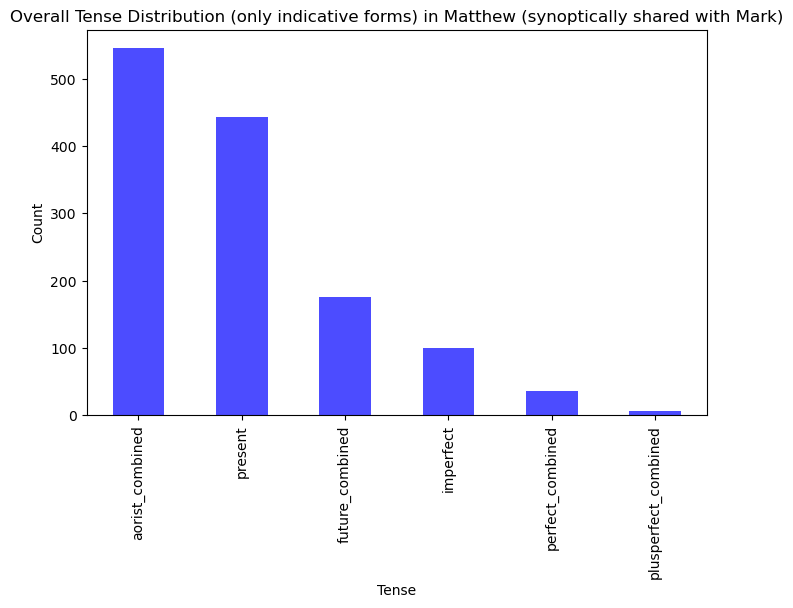

In [68]:
tense_counts= SynopticMatthewVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Matthew (synoptically shared with Mark)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

In Matthew the most dominent tense is the Aorist tense. This is particularly true if we take both 

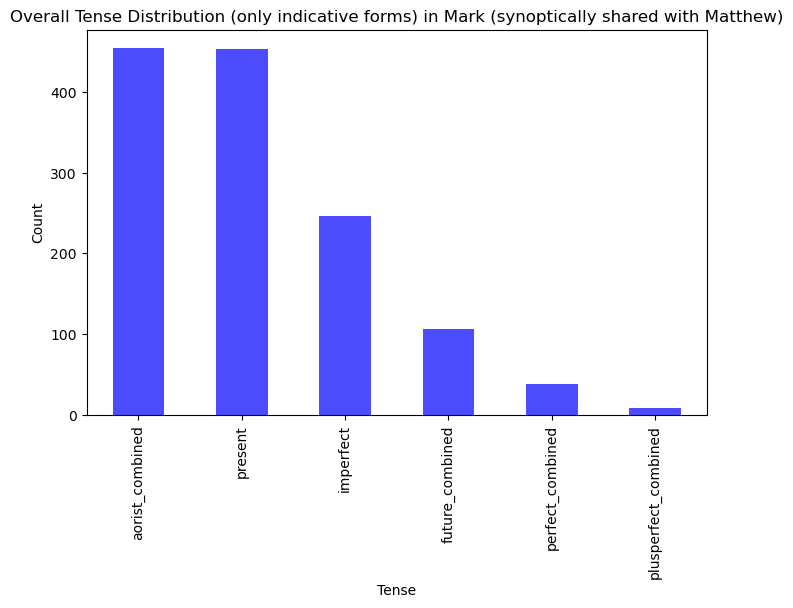

In [69]:
tense_counts= SynopticMarkVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Mark (synoptically shared with Matthew)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

#### What verbal forms are used with what tense?

In [70]:
SynopticMatthewVerbs[SynopticMatthewVerbs['combitense'].str.contains('present')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
εἰμί,111,111,111,111,111,111,111,111,111,111,111,111,111,110,111,111
λέγω,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83
ἔχω,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
θέλω,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16
δύναμαι,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ποιέω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ἔρχομαι,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
ἐκβάλλω,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
ἀφίημι,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [71]:
SynopticMarkVerbs[SynopticMarkVerbs['combitense'].str.contains('present')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,91,91,91,91,91,91,90,90,90,91,91,91,91,91,91,91
εἰμί,90,90,90,90,90,90,89,89,89,90,90,90,90,87,90,90
ἔχω,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23
ἔρχομαι,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
δύναμαι,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
ποιέω,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
θέλω,9,9,9,9,9,9,8,8,8,9,9,9,9,9,9,9
ἐσθίω,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
γίνομαι,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


In [72]:
SynopticMatthewVerbs[SynopticMatthewVerbs['combitense'].str.contains('aorist')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,109,109,109,109,109,109,109,109,109,109,109,109,109,109,109,109
προσέρχομαι,17,17,17,17,17,17,16,16,16,17,17,17,17,17,17,17
ἔρχομαι,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15
ἀκολουθέω,12,12,12,12,12,12,11,11,11,12,12,12,12,12,12,12
γίνομαι,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
ὁράω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ποιέω,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
θεραπεύω,9,9,9,9,9,9,8,8,8,9,9,9,9,9,9,9
λαμβάνω,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


In [73]:
SynopticMarkVerbs[SynopticMarkVerbs['combitense'].str.contains('aorist')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,67,67,67,67,67,67,66,66,66,67,67,67,67,67,67,67
ἄρχω,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
ἔρχομαι,19,19,19,19,19,19,19,19,19,19,19,19,19,19,19,19
γίνομαι,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17
ὁράω,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14
ἐξέρχομαι,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
ἀπέρχομαι,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
ἀποκρίνομαι,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
δίδωμι,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


### Mark's and Matthews shared healing episodes

In [74]:
MThealing=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat')) & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Heal', case=False))]
MThealing['bol_monad_num'].value_counts().sum()

np.int64(603)

In [75]:
MKhealing=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark')) & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Heal', case=False))]
MKhealing['bol_monad_num'].value_counts().sum()

np.int64(968)

In [76]:
MThealing[(MThealing["sp"].str.contains('verb'))].value_counts().sum()

np.int64(152)

In [77]:
MKhealing[(MKhealing["sp"].str.contains('verb'))].value_counts().sum()

np.int64(242)

In [78]:
MThealing[(MThealing["sp"].str.contains('verb')) & (MThealing["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(83)

In [79]:
MKhealing[(MKhealing["sp"].str.contains('verb')) & (MKhealing["bol_mood"].str.contains('indicative'))].value_counts().sum()

np.int64(136)

In [80]:
MThealing[(MThealing["sp"].str.contains('verb')) & (MThealing["bol_mood"].str.contains('indicative')) &  (MThealing["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(51)

In [81]:
MKhealing[(MKhealing["sp"].str.contains('verb')) & (MKhealing["bol_mood"].str.contains('indicative')) &  (MKhealing["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(57)

In [82]:
MThealing[(MThealing["sp"].str.contains('verb')) & (MThealing["bol_mood"].str.contains('indicative')) &  (MThealing["combitense"].str.contains('present'))].value_counts().sum()

np.int64(15)

In [83]:
MKhealing[(MKhealing["sp"].str.contains('verb')) & (MKhealing["bol_mood"].str.contains('indicative')) &  (MKhealing["combitense"].str.contains('present'))].value_counts().sum()

np.int64(43)

#### Ratio calculations for shared synoptic materials

Clearly the two most dominant tenses in all healing episodes are the Present Tense and the Aorist Tense. However, are these two tenses evenly distributed over the different gospel versions?

In [84]:
MatthewHealingIndicativeVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat')) 
                                            & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Heal', case=False))
                                            & (MMSharedSynopticMaterials["sp"].str.contains('verb')) 
                                            & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative')) 
                                             ]

MarkHealingIndicativeVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark')) 
                                            & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Heal', case=False))
                                            & (MMSharedSynopticMaterials["sp"].str.contains('verb')) 
                                            & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative')) 
                                             ]

In [85]:
MatthewHealingIndicativeVerbs[(MatthewHealingIndicativeVerbs["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(51)

In [86]:
MatthewHealingIndicativeVerbs[(MatthewHealingIndicativeVerbs["combitense"].str.contains('present'))].value_counts().sum()

np.int64(15)

In [87]:
MarkHealingIndicativeVerbs[(MarkHealingIndicativeVerbs["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(57)

In [88]:
MarkHealingIndicativeVerbs[(MarkHealingIndicativeVerbs["combitense"].str.contains('present'))].value_counts().sum()

np.int64(43)

In [89]:
MatthewHealingIndicativeVerbs['combitense'].value_counts()

combitense
aorist_combined    51
present            15
future_combined    13
imperfect           4
Name: count, dtype: int64

In [90]:
MarkHealingIndicativeVerbs['combitense'].value_counts()

combitense
aorist_combined         57
present                 43
imperfect               31
perfect_combined         3
future_combined          2
plusperfect_combined     1
Name: count, dtype: int64

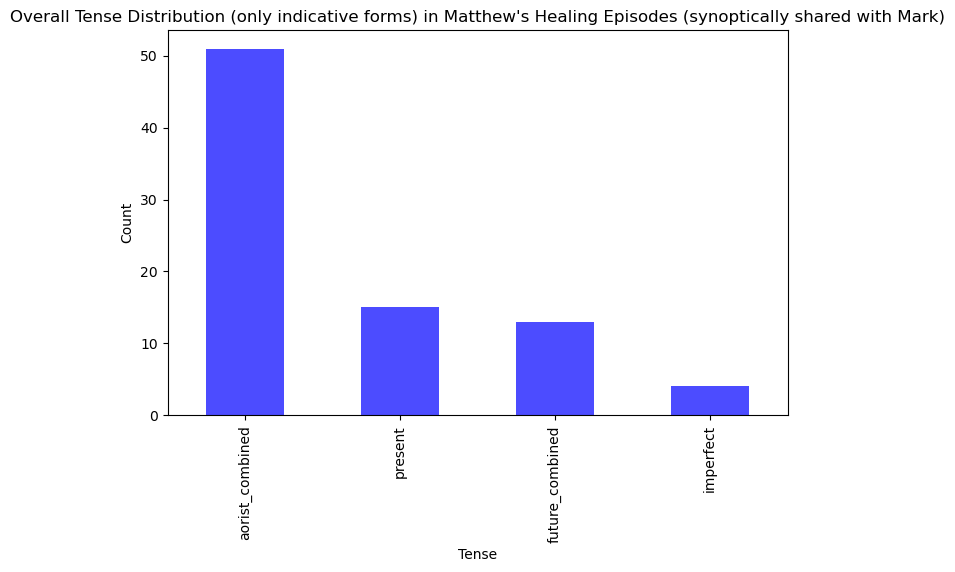

In [91]:
tense_countsMT= MatthewHealingIndicativeVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_countsMT.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Matthew\'s Healing Episodes (synoptically shared with Mark)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

In Matthew the most dominent tense is the Aorist tense. This is particularly true if we take both 

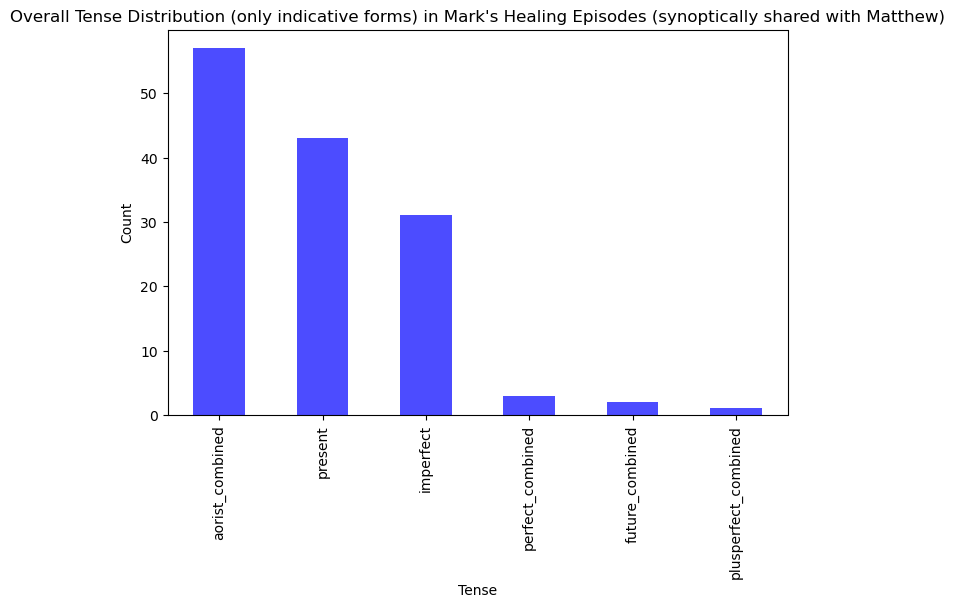

In [92]:
tense_counts= MarkHealingIndicativeVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Mark\'s Healing Episodes (synoptically shared with Matthew)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

#### What verbal forms are used with what tense?

In [93]:
SynopticMatthewVerbs[SynopticMatthewVerbs['combitense'].str.contains('present')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
εἰμί,111,111,111,111,111,111,111,111,111,111,111,111,111,110,111,111
λέγω,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83
ἔχω,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
θέλω,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16
δύναμαι,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ποιέω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ἔρχομαι,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
ἐκβάλλω,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
ἀφίημι,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [94]:
SynopticMarkVerbs[SynopticMarkVerbs['combitense'].str.contains('present')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,91,91,91,91,91,91,90,90,90,91,91,91,91,91,91,91
εἰμί,90,90,90,90,90,90,89,89,89,90,90,90,90,87,90,90
ἔχω,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23
ἔρχομαι,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
δύναμαι,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
ποιέω,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
θέλω,9,9,9,9,9,9,8,8,8,9,9,9,9,9,9,9
ἐσθίω,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
γίνομαι,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


In [95]:
SynopticMatthewVerbs[SynopticMatthewVerbs['combitense'].str.contains('aorist')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,109,109,109,109,109,109,109,109,109,109,109,109,109,109,109,109
προσέρχομαι,17,17,17,17,17,17,16,16,16,17,17,17,17,17,17,17
ἔρχομαι,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15
ἀκολουθέω,12,12,12,12,12,12,11,11,11,12,12,12,12,12,12,12
γίνομαι,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
ὁράω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ποιέω,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
θεραπεύω,9,9,9,9,9,9,8,8,8,9,9,9,9,9,9,9
λαμβάνω,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


In [96]:
SynopticMarkVerbs[SynopticMarkVerbs['combitense'].str.contains('aorist')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,67,67,67,67,67,67,66,66,66,67,67,67,67,67,67,67
ἄρχω,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
ἔρχομαι,19,19,19,19,19,19,19,19,19,19,19,19,19,19,19,19
γίνομαι,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17
ὁράω,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14
ἐξέρχομαι,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
ἀπέρχομαι,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
ἀποκρίνομαι,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
δίδωμι,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


### Passion in Mark and Matthew

#### Present Tense in Mark and Matthew

In [97]:
MatMarPassion = MatMarSynopticMaterialsVerbs[MatMarSynopticMaterialsVerbs["AlandSynopEvent"].str.contains('Pass', na=False)]
MatMarPassion.head(5)


,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
4317,383262,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,ἤρξατο,The Way to the Cross,Jesus Foretells His Passion,9.0,ἄρχω,9567,indicative,aorist,middle_deponent,Pred,verb,aorist_combined
4320,383262,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,δεικνύειν,The Way to the Cross,Jesus Foretells His Passion,9.0,δείκνυμι,9570,infinitive,present,active,Pred,verb,present
4325,383262,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,δεῖ,The Way to the Cross,Jesus Foretells His Passion,9.0,δεῖ,9575,indicative,present,active,Pred,verb,present
4329,383262,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,ἀπελθεῖν,The Way to the Cross,Jesus Foretells His Passion,9.0,ἀπέρχομαι,9579,infinitive,second_aorist,active,Pred,verb,aorist_combined
4332,383262,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,παθεῖν,The Way to the Cross,Jesus Foretells His Passion,9.0,πάσχω,9582,infinitive,second_aorist,active,Pred,verb,aorist_combined


In [98]:
MatMarPassionPresentTense=MatMarPassion[(MatMarPassion["combitense"].str.contains('present'))
                          &
                          (MatMarPassion["bol_mood"].str.contains('indicative'))
                           ]
MatMarPassionPresentTense.head(5)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
4325,383262,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,δεῖ,The Way to the Cross,Jesus Foretells His Passion,9.0,δεῖ,9575,indicative,present,active,Pred,verb,present
4375,383264,"ὁ δὲ στραφεὶς εἶπεν τῷ Πέτρῳ Ὕπαγε ὀπίσω μου, ...",Matthew,16,23,εἶ,The Way to the Cross,Jesus Foretells His Passion,9.0,εἰμί,9625,indicative,present,active,PreC,verb,present
4379,383264,"ὁ δὲ στραφεὶς εἶπεν τῷ Πέτρῳ Ὕπαγε ὀπίσω μου, ...",Matthew,16,23,φρονεῖς,The Way to the Cross,Jesus Foretells His Passion,9.0,φρονέω,9629,indicative,present,active,Pred,verb,present
4762,383290,Συστρεφομένων δὲ αὐτῶν ἐν τῇ Γαλιλαίᾳ εἶπεν αὐ...,Matthew,17,22,Μέλλει,The Way to the Cross,Jesus Foretells His Passion again,9.0,μέλλω,10129,indicative,present,active,Pred,verb,present
5525,383377,"Ἰδοὺ ἀναβαίνομεν εἰς Ἱεροσόλυμα, καὶ ὁ Υἱὸς το...",Matthew,20,18,ἀναβαίνομεν,The Ministry in Judea,The Third Prediction of the Passion,12.0,ἀναβαίνω,11700,indicative,present,active,Pred,verb,present


In [99]:
MatMarPassionAoristTense=MatMarPassion[(MatMarPassion["combitense"].str.contains('aorist'))
                          &
                          (MatMarPassion["bol_mood"].str.contains('indicative'))
                           ]
MatMarPassionAoristTense.head(5)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_lemma,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
4317,383262,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,ἤρξατο,The Way to the Cross,Jesus Foretells His Passion,9.0,ἄρχω,9567,indicative,aorist,middle_deponent,Pred,verb,aorist_combined
4352,383263,καὶ προσλαβόμενος αὐτὸν ὁ Πέτρος ἤρξατο ἐπιτιμ...,Matthew,16,22,ἤρξατο,The Way to the Cross,Jesus Foretells His Passion,9.0,ἄρχω,9602,indicative,aorist,middle_deponent,Pred,verb,aorist_combined
4367,383264,"ὁ δὲ στραφεὶς εἶπεν τῷ Πέτρῳ Ὕπαγε ὀπίσω μου, ...",Matthew,16,23,εἶπεν,The Way to the Cross,Jesus Foretells His Passion,9.0,λέγω,9617,indicative,second_aorist,active,Pred,verb,aorist_combined
4758,383290,Συστρεφομένων δὲ αὐτῶν ἐν τῇ Γαλιλαίᾳ εἶπεν αὐ...,Matthew,17,22,εἶπεν,The Way to the Cross,Jesus Foretells His Passion again,9.0,λέγω,10125,indicative,second_aorist,active,Pred,verb,aorist_combined
4780,383291,"καὶ ἀποκτενοῦσιν αὐτόν, καὶ τῇ τρίτῃ ἡμέρᾳ ἐγε...",Matthew,17,23,ἐλυπήθησαν,The Way to the Cross,Jesus Foretells His Passion again,9.0,λυπέω,10147,indicative,aorist,passive,Pred,verb,aorist_combined


#### Ratio calculations for shared synoptic materials

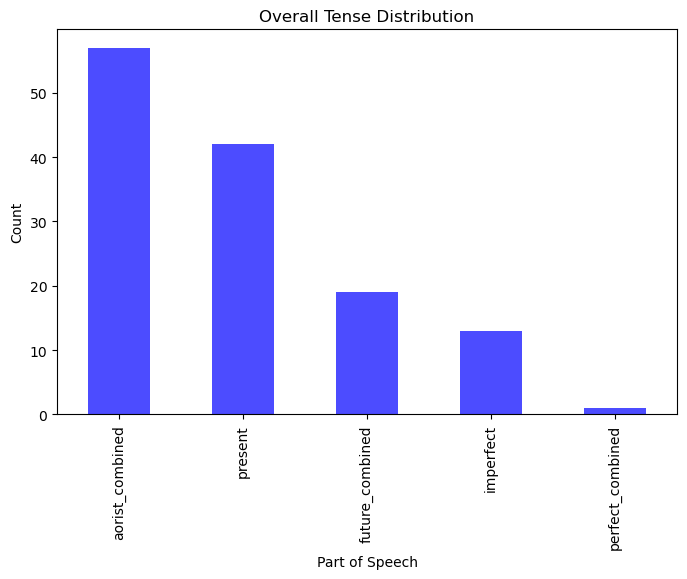

In [100]:
tense_counts= MatMarPassion['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution')
plt.xlabel('Part of Speech')
plt.ylabel('Count')
plt.show()

Clearly the two most dominant tenses in all healing episodes are the Present Tense and the Aorist Tense. However, are these two tenses evenly distributed over the different gospel versions?

In [101]:
PassionMatthewVerbs=MatMarPassion[(MatMarPassion["book"].str.contains('Mat')) & (MatMarPassion["bol_mood"].str.contains('indicative'))]
PassionMarkVerbs=MatMarPassion[(MatMarPassion["book"].str.contains('Mark')) & (MatMarPassion["bol_mood"].str.contains('indicative'))]


In [102]:
PassionMatthewVerbs[(PassionMatthewVerbs["bol_tense"].str.contains('aorist')) & (SynopticMatthewVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

/var/folders/1f/9k898mgs2dx82j7lfyf14c_40000gp/T/ipykernel_39906/2040852994.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  PassionMatthewVerbs[(PassionMatthewVerbs["bol_tense"].str.contains('aorist')) & (SynopticMatthewVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()


np.int64(12)

In [103]:
PassionMatthewVerbs[(PassionMatthewVerbs["bol_tense"].str.contains('present')) & (SynopticMatthewVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

/var/folders/1f/9k898mgs2dx82j7lfyf14c_40000gp/T/ipykernel_39906/1736168244.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  PassionMatthewVerbs[(PassionMatthewVerbs["bol_tense"].str.contains('present')) & (SynopticMatthewVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()


np.int64(9)

In [104]:
PassionMarkVerbs[(PassionMarkVerbs["bol_tense"].str.contains('aorist')) & (SynopticMarkVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

/var/folders/1f/9k898mgs2dx82j7lfyf14c_40000gp/T/ipykernel_39906/32686569.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  PassionMarkVerbs[(PassionMarkVerbs["bol_tense"].str.contains('aorist')) & (SynopticMarkVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()


np.int64(9)

In [105]:
PassionMarkVerbs[(PassionMarkVerbs["bol_tense"].str.contains('present')) & (SynopticMarkVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()

/var/folders/1f/9k898mgs2dx82j7lfyf14c_40000gp/T/ipykernel_39906/428964122.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  PassionMarkVerbs[(PassionMarkVerbs["bol_tense"].str.contains('present')) & (SynopticMarkVerbs["bol_mood"].str.contains('indicative'))].value_counts().sum()


np.int64(12)

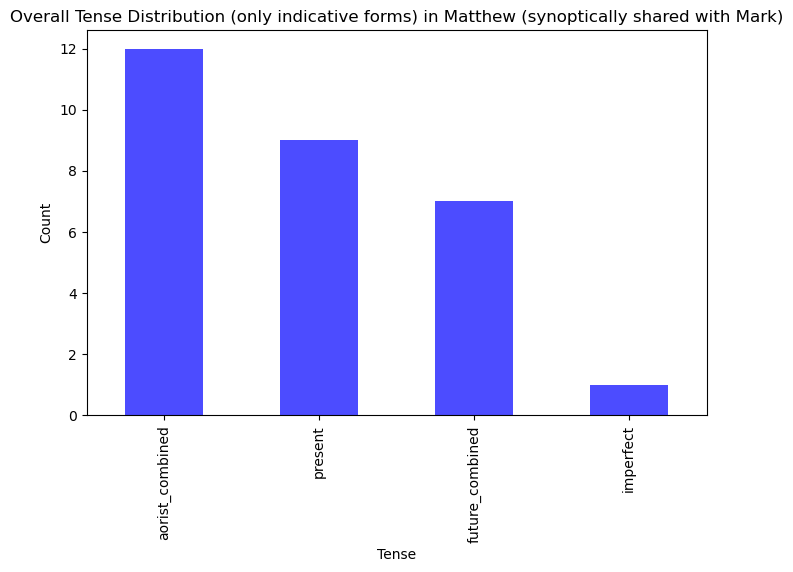

In [106]:
tense_counts= PassionMatthewVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Matthew (synoptically shared with Mark)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

In Matthew the most dominent tense is the Aorist tense. This is particularly true if we take both 

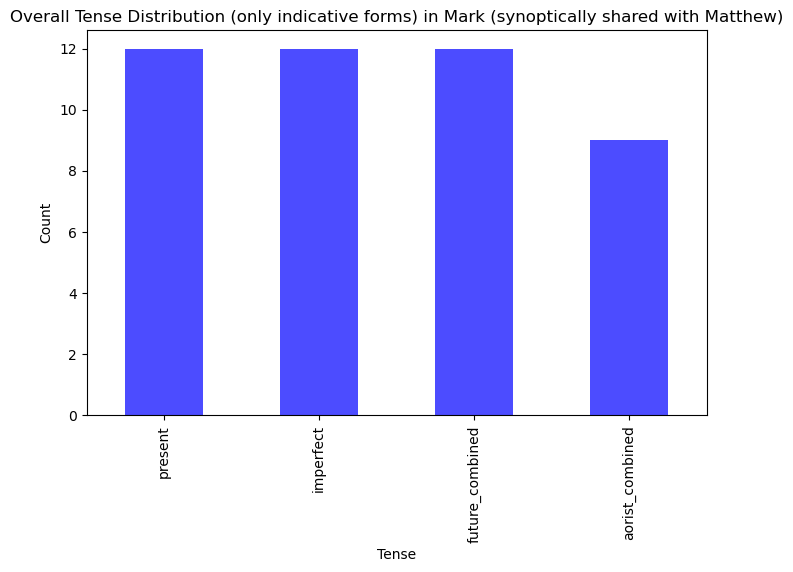

In [107]:
tense_counts= PassionMarkVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Mark (synoptically shared with Matthew)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

#### What verbal forms are used with what tense?

In [108]:
SynopticMatthewVerbs[SynopticMatthewVerbs['combitense'].str.contains('present')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
εἰμί,111,111,111,111,111,111,111,111,111,111,111,111,111,110,111,111
λέγω,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83
ἔχω,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
θέλω,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16
δύναμαι,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ποιέω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ἔρχομαι,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
ἐκβάλλω,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
ἀφίημι,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [109]:
SynopticMarkVerbs[SynopticMarkVerbs['combitense'].str.contains('present')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,91,91,91,91,91,91,90,90,90,91,91,91,91,91,91,91
εἰμί,90,90,90,90,90,90,89,89,89,90,90,90,90,87,90,90
ἔχω,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23
ἔρχομαι,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
δύναμαι,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
ποιέω,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
θέλω,9,9,9,9,9,9,8,8,8,9,9,9,9,9,9,9
ἐσθίω,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
γίνομαι,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


In [110]:
SynopticMatthewVerbs[SynopticMatthewVerbs['combitense'].str.contains('aorist')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,109,109,109,109,109,109,109,109,109,109,109,109,109,109,109,109
προσέρχομαι,17,17,17,17,17,17,16,16,16,17,17,17,17,17,17,17
ἔρχομαι,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15
ἀκολουθέω,12,12,12,12,12,12,11,11,11,12,12,12,12,12,12,12
γίνομαι,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
ὁράω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ποιέω,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
θεραπεύω,9,9,9,9,9,9,8,8,8,9,9,9,9,9,9,9
λαμβάνω,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


In [111]:
SynopticMarkVerbs[SynopticMarkVerbs['combitense'].str.contains('aorist')].groupby(['bol_lemma']).count().sort_values(['combitense'], ascending=(False)).head(10)

,verse_node,verse_text,book,chapter,verse,word_text,AlandSynopChapter,AlandSynopEvent,AlandSynopNo2,bol_monad_num,bol_mood,bol_tense,bol_voice2,function,sp,combitense
bol_lemma,,,,,,,,,,,,,,,,
λέγω,67,67,67,67,67,67,66,66,66,67,67,67,67,67,67,67
ἄρχω,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22
ἔρχομαι,19,19,19,19,19,19,19,19,19,19,19,19,19,19,19,19
γίνομαι,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17
ὁράω,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14
ἐξέρχομαι,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
ἀπέρχομαι,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
ἀποκρίνομαι,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
δίδωμι,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


#### Passion with HPT in Mark

In [112]:
HealingHPTinMark=SynopSelection[(SynopSelection["AlandSynopEvent2"].str.contains('Pass'))
                          &
                          (SynopSelection["combitense"].str.contains('present'))
                          &
                          (SynopSelection["bol_mood2"].str.contains('indicative'))
                          &
                          (SynopSelection["book1"].str.contains('Mark'))
                           ]
HealingHPTinMark.head(200)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
4738,4739,Mark,8,31,384096,verse,Καὶ ἤρξατο διδάσκειν αὐτοὺς ὅτι δεῖ τὸν Υἱὸν τ...,Mark,8,31,23510,word,δεῖ,The Way to the Cross,Jesus Foretells His Passion,159.0,δεῖ,23510,indicative,present,active,Pred,dei,verb,present
4750,4751,Mark,8,33,384098,verse,ὁ δὲ ἐπιστραφεὶς καὶ ἰδὼν τοὺς μαθητὰς αὐτοῦ ἐ...,Mark,8,33,23559,word,λέγει,The Way to the Cross,Jesus Foretells His Passion,159.0,λέγω,23559,indicative,present,active,Pred,lego,verb,present
4752,4753,Mark,8,33,384098,verse,ὁ δὲ ἐπιστραφεὶς καὶ ἰδὼν τοὺς μαθητὰς αὐτοῦ ἐ...,Mark,8,33,23566,word,φρονεῖς,The Way to the Cross,Jesus Foretells His Passion,159.0,φρονέω,23566,indicative,present,active,Pred,phroneo,verb,present
4895,4896,Mark,9,31,384134,verse,"ἐδίδασκεν γὰρ τοὺς μαθητὰς αὐτοῦ, καὶ ἔλεγεν α...",Mark,9,31,24212,word,παραδίδοται,The Way to the Cross,Jesus Foretells His Passion again,164.0,παραδίδωμι,24212,indicative,present,middle_or_passive,Pred,paradidomi,verb,present
5070,5071,Mark,10,33,384184,verse,"ὅτι Ἰδοὺ ἀναβαίνομεν εἰς Ἱεροσόλυμα, καὶ ὁ Υἱὸ...",Mark,10,33,25069,word,ἀναβαίνομεν,The Ministry in Judea,The Third Prediction of the Passion,262.0,ἀναβαίνω,25069,indicative,present,active,Pred,anabaino,verb,present
5590,5591,Mark,14,12,384328,verse,"Καὶ τῇ πρώτῃ ἡμέρᾳ τῶν ἀζύμων, ὅτε τὸ πάσχα ἔθ...",Mark,14,12,27577,word,λέγουσιν,The Passion Narrative,Preparation for the Passover,308.0,λέγω,27577,indicative,present,active,Pred,lego,verb,present
5591,5592,Mark,14,12,384328,verse,"Καὶ τῇ πρώτῃ ἡμέρᾳ τῶν ἀζύμων, ὅτε τὸ πάσχα ἔθ...",Mark,14,12,27583,word,θέλεις,The Passion Narrative,Preparation for the Passover,308.0,θέλω,27583,indicative,present,active,Pred,thelo,verb,present
5595,5596,Mark,14,13,384329,verse,καὶ ἀποστέλλει δύο τῶν μαθητῶν αὐτοῦ καὶ λέγει...,Mark,14,13,27591,word,ἀποστέλλει,The Passion Narrative,Preparation for the Passover,308.0,ἀποστέλλω,27591,indicative,present,active,Pred,apostello,verb,present
5596,5597,Mark,14,13,384329,verse,καὶ ἀποστέλλει δύο τῶν μαθητῶν αὐτοῦ καὶ λέγει...,Mark,14,13,27597,word,λέγει,The Passion Narrative,Preparation for the Passover,308.0,λέγω,27597,indicative,present,active,Pred,lego,verb,present
5603,5604,Mark,14,14,384330,verse,καὶ ὅπου ἐὰν εἰσέλθῃ εἴπατε τῷ οἰκοδεσπότῃ ὅτι...,Mark,14,14,27622,word,λέγει,The Passion Narrative,Preparation for the Passover,308.0,λέγω,27622,indicative,present,active,Pred,lego,verb,present


#### Passion with HPT in Matthew

In [113]:
HealingHPTinMatt=SynopSelection[(SynopSelection["AlandSynopEvent2"].str.contains('Pass'))
                          &
                          (SynopSelection["combitense"].str.contains('present'))
                          &
                          (SynopSelection["bol_mood2"].str.contains('indicative'))
                          &
                          (SynopSelection["book1"].str.contains('Matt'))
                           ]
HealingHPTinMatt.head(200)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
1846,1847,Matthew,16,21,383262,verse,Ἀπὸ τότε ἤρξατο Ἰησοῦς Χριστὸς δεικνύειν τοῖς ...,Matthew,16,21,9575,word,δεῖ,The Way to the Cross,Jesus Foretells His Passion,159.0,δεῖ,9575,indicative,present,active,Pred,dei,verb,present
1858,1859,Matthew,16,23,383264,verse,"ὁ δὲ στραφεὶς εἶπεν τῷ Πέτρῳ Ὕπαγε ὀπίσω μου, ...",Matthew,16,23,9629,word,φρονεῖς,The Way to the Cross,Jesus Foretells His Passion,159.0,φρονέω,9629,indicative,present,active,Pred,phroneo,verb,present
1963,1964,Matthew,17,22,383290,verse,Συστρεφομένων δὲ αὐτῶν ἐν τῇ Γαλιλαίᾳ εἶπεν αὐ...,Matthew,17,22,10129,word,Μέλλει,The Way to the Cross,Jesus Foretells His Passion again,164.0,μέλλω,10129,indicative,present,active,Pred,mello,verb,present
2286,2287,Matthew,20,18,383377,verse,"Ἰδοὺ ἀναβαίνομεν εἰς Ἱεροσόλυμα, καὶ ὁ Υἱὸς το...",Matthew,20,18,11700,word,ἀναβαίνομεν,The Ministry in Judea,The Third Prediction of the Passion,262.0,ἀναβαίνω,11700,indicative,present,active,Pred,anabaino,verb,present
3106,3107,Matthew,26,17,383637,verse,Τῇ δὲ πρώτῃ τῶν ἀζύμων προσῆλθον οἱ μαθηταὶ τῷ...,Matthew,26,17,15955,word,θέλεις,The Passion Narrative,Preparation for the Passover,308.0,θέλω,15955,indicative,present,active,Pred,thelo,verb,present
3112,3113,Matthew,26,18,383638,verse,ὁ δὲ εἶπεν Ὑπάγετε εἰς τὴν πόλιν πρὸς τὸν δεῖν...,Matthew,26,18,15976,word,λέγει,The Passion Narrative,Preparation for the Passover,308.0,λέγω,15976,indicative,present,active,Pred,lego,verb,present
3113,3114,Matthew,26,18,383638,verse,ὁ δὲ εἶπεν Ὑπάγετε εἰς τὴν πόλιν πρὸς τὸν δεῖν...,Matthew,26,18,15984,word,ποιῶ,The Passion Narrative,Preparation for the Passover,308.0,ποιέω,15984,indicative,present,active,Pred,poieo,verb,present


### Mark's and Matthews shared parables

In [114]:
MTparable=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat')) & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Parabl', case=False))]
MTparable['bol_monad_num'].value_counts().sum()

np.int64(821)

In [115]:
MKparable=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark')) & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Parabl', case=False))]
MKparable['bol_monad_num'].value_counts().sum()

np.int64(699)

#### Ratio calculations for shared synoptic materials

Clearly the two most dominant tenses in all healing episodes are the Present Tense and the Aorist Tense. However, are these two tenses evenly distributed over the different gospel versions?

In [116]:
MatthewParableIndicativeVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat')) 
                                            & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Parabl', case=False))
                                            & (MMSharedSynopticMaterials["sp"].str.contains('verb')) 
                                            & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative')) 
                                             ]

MarkParableIndicativeVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark')) 
                                            & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Parabl', case=False))
                                            & (MMSharedSynopticMaterials["sp"].str.contains('verb')) 
                                            & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative')) 
                                             ]

In [117]:
MatthewParableIndicativeVerbs[(MatthewParableIndicativeVerbs["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(47)

In [118]:
MatthewParableIndicativeVerbs[(MatthewParableIndicativeVerbs["combitense"].str.contains('present'))].value_counts().sum()

np.int64(38)

In [119]:
MarkParableIndicativeVerbs[(MarkParableIndicativeVerbs["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(44)

In [120]:
MarkParableIndicativeVerbs[(MarkParableIndicativeVerbs["combitense"].str.contains('present'))].value_counts().sum()

np.int64(31)

In [121]:
MatthewParableIndicativeVerbs['combitense'].value_counts()

combitense
aorist_combined         47
present                 40
future_combined         18
imperfect                6
perfect_combined         3
plusperfect_combined     1
Name: count, dtype: int64

In [122]:
MarkParableIndicativeVerbs['combitense'].value_counts()

combitense
aorist_combined     44
present             31
imperfect           16
future_combined      9
perfect_combined     3
Name: count, dtype: int64

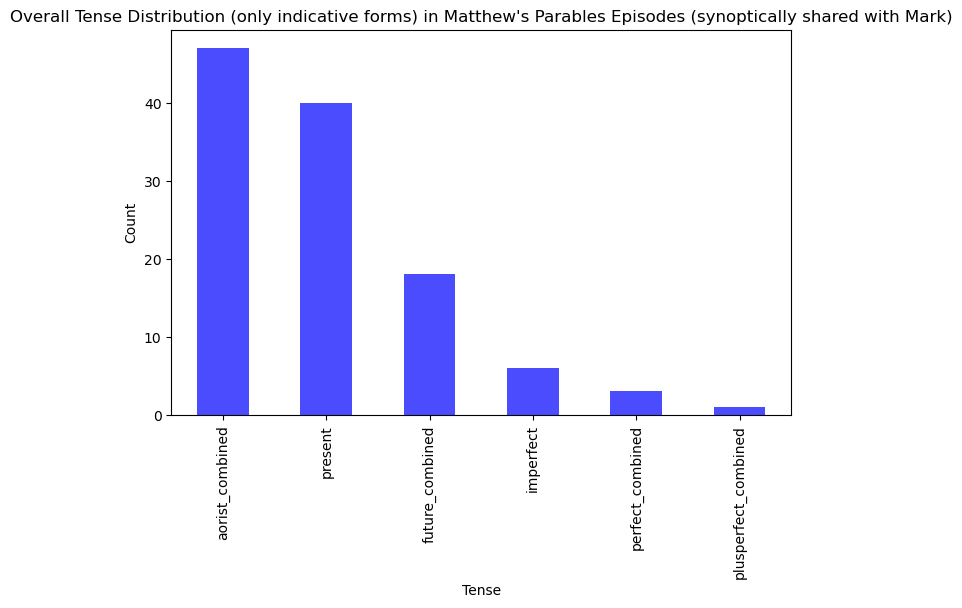

In [123]:
tense_countsMT= MatthewParableIndicativeVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_countsMT.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Matthew\'s Parables Episodes (synoptically shared with Mark)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

In Matthew the most dominent tense is the Aorist tense. This is particularly true if we take both 

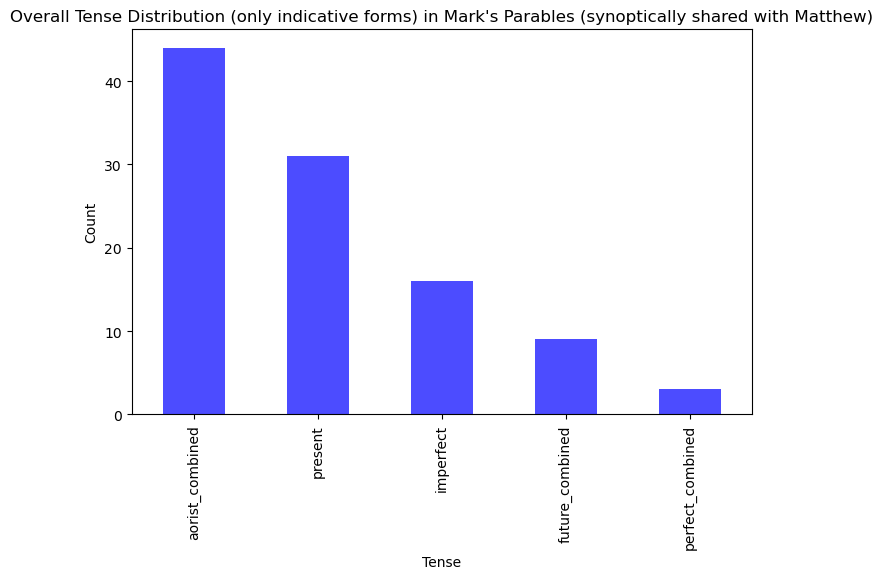

In [124]:
tense_counts= MarkParableIndicativeVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Mark\'s Parables (synoptically shared with Matthew)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

### Mark's and Matthews shared discourses with the Pharisees

In [125]:
MTdiscourse=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat')) & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Phari', case=False))]
MTdiscourse['bol_monad_num'].value_counts().sum()

np.int64(777)

In [126]:
MKdiscourse=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark')) & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Phari', case=False))]
MKdiscourse['bol_monad_num'].value_counts().sum()

np.int64(196)

#### Ratio calculations for shared synoptic materials

Clearly the two most dominant tenses in all healing episodes are the Present Tense and the Aorist Tense. However, are these two tenses evenly distributed over the different gospel versions?

In [127]:
MatthewDiscourseIndicativeVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mat')) 
                                            & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Phari', case=False))
                                            & (MMSharedSynopticMaterials["sp"].str.contains('verb')) 
                                            & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative')) 
                                             ]

MarkDiscourseIndicativeVerbs=MMSharedSynopticMaterials[(MMSharedSynopticMaterials["book"].str.contains('Mark')) 
                                            & (MMSharedSynopticMaterials["AlandSynopEvent"].str.contains('Phari', case=False))
                                            & (MMSharedSynopticMaterials["sp"].str.contains('verb')) 
                                            & (MMSharedSynopticMaterials["bol_mood"].str.contains('indicative')) 
                                             ]

In [128]:
MatthewDiscourseIndicativeVerbs[(MatthewDiscourseIndicativeVerbs["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(16)

In [129]:
MatthewDiscourseIndicativeVerbs[(MatthewDiscourseIndicativeVerbs["combitense"].str.contains('present'))].value_counts().sum()

np.int64(52)

In [130]:
MarkDiscourseIndicativeVerbs[(MarkDiscourseIndicativeVerbs["combitense"].str.contains('aorist'))].value_counts().sum()

np.int64(7)

In [131]:
MarkDiscourseIndicativeVerbs[(MarkDiscourseIndicativeVerbs["combitense"].str.contains('present'))].value_counts().sum()

np.int64(14)

In [132]:
MatthewDiscourseIndicativeVerbs['combitense'].value_counts()

combitense
present            52
aorist_combined    16
future_combined    11
imperfect           4
Name: count, dtype: int64

In [133]:
MarkDiscourseIndicativeVerbs['combitense'].value_counts()

combitense
present            16
aorist_combined     7
imperfect           5
future_combined     2
Name: count, dtype: int64

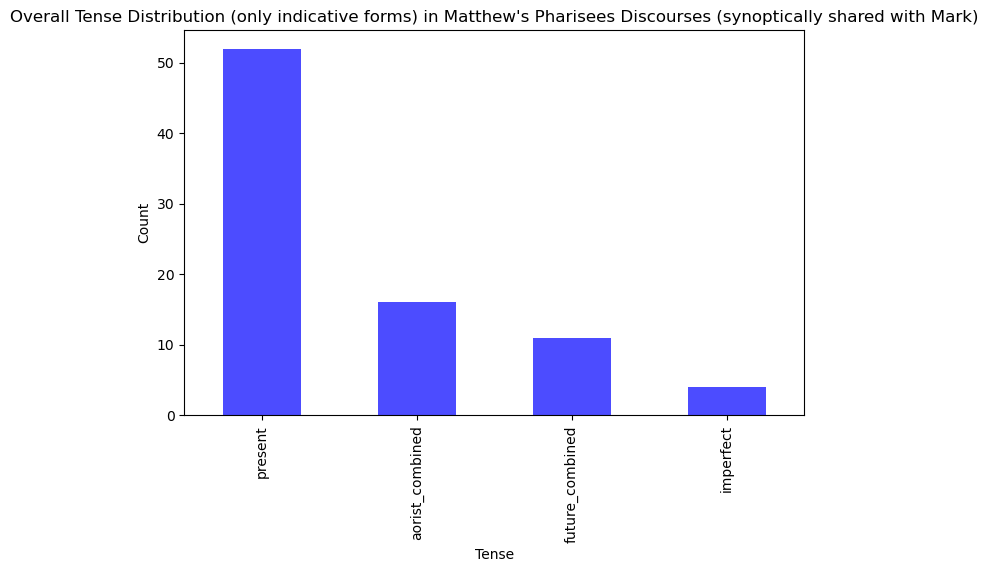

In [134]:
tense_countsMT= MatthewDiscourseIndicativeVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_countsMT.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Matthew\'s Pharisees Discourses (synoptically shared with Mark)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

In Matthew the most dominent tense is the Aorist tense. This is particularly true if we take both 

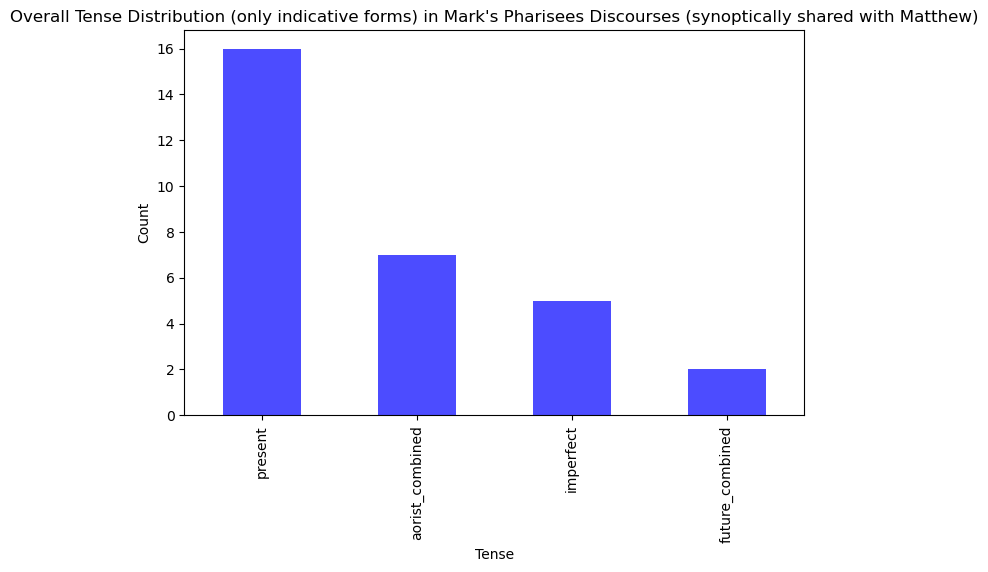

In [135]:
tense_counts= MarkDiscourseIndicativeVerbs['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution (only indicative forms) in Mark\'s Pharisees Discourses (synoptically shared with Matthew)')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

### Speaking of Jesus


´´´
b1:verse book=Matthew chapter* verse*
 c1:clause
   p1:phrase function=Subj
       w1:word lemmatranslit=Iesous AlandSynopEvent*
   p2:phrase function=Pred
       w2:word lemmatranslit=lego AlandSynopEvent* bol_tense~.*aorist.* bol_mood*
       
b2:verse book=Mark chapter* verse*
 c2:clause
   p3:phrase function=Subj
       w3:word lemmatranslit=Iesous AlandSynopEvent*
   p4:phrase function=Pred
       w4:word lemmatranslit=lego AlandSynopEvent* bol_tense=present bol_mood=indicative


p1 -parent> c1
p2 -parent> c1

p3 -parent> c2
p4 -parent> c2

w1 .AlandSynopEvent=AlandSynopEvent. w3

´´´

´´´
b1:verse book=Matthew chapter* verse*
 c1:clause
   p1:phrase function=Subj
       w1:word lemmatranslit=Iesous AlandSynopEvent*
   p2:phrase function=Pred
       w2:word lemmatranslit=lego AlandSynopEvent* bol_tense=present bol_mood=indicative
       
b2:verse book=Mark chapter* verse*
 c2:clause
   p3:phrase function=Subj
       w3:word lemmatranslit=Iesous AlandSynopEvent*
   p4:phrase function=Pred
       w4:word lemmatranslit=lego AlandSynopEvent* bol_tense* bol_mood=indicative


p1 -parent> c1
p2 -parent> c1

p3 -parent> c2
p4 -parent> c2

w1 .AlandSynopEvent=AlandSynopEvent. w3

´´´

In [136]:
MatMarHealing = '''
b1:verse book=Matthew chapter* verse*
 c1:clause
   p1:phrase function=Subj
       w1:word lemmatranslit=Iesous AlandSynopEvent*
   p2:phrase function=Pred
       w2:word lemmatranslit=lego|apokrinomai|phoneo AlandSynopEvent* bol_tense~aorist bol_mood=indicative



'''
MatMarHealing = N1904.search(MatMarHealing)
N1904.table(MatMarHealing, start=1, end=2, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.20s 33 results


n,p,verse,phrase (+1),phrase (+1),clause (+1),phrase (+1),clause (+1)
1,Matthew 3:15,,Ἰησοῦς,εἶπεν,ἀποκριθεὶς ὁ Ἰησοῦς εἶπεν αὐτῷ Ἄφες ἄρτι· οὕτως γὰρ πρέπον ἐστὶν ἡμῖν πληρῶσαι πᾶσαν δικαιοσύνην.,ὁ Ἰησοῦς,εἶπεν
2,Matthew 8:10,,ὁ Ἰησοῦς,εἶπεν,Ἰησοῦς,εἶπεν,"ἀκούσας ὁ Ἰησοῦς ἐθαύμασεν καὶ εἶπεν τοῖς ἀκολουθοῦσιν Ἀμὴν λέγω ὑμῖν, παρ’ οὐδενὶ τοσαύτην πίστιν ἐν τῷ Ἰσραὴλ εὗρον."


In [137]:
MatMarSpeaking1 = '''
b1:verse book=Matthew chapter* verse*
 c1:clause
   p1:phrase function=Subj
       w1:word lemmatranslit=Iesous AlandSynopEvent*
   p2:phrase function=Pred
       w2:word lemmatranslit=lego|apokrinomai|phoneo AlandSynopEvent* bol_tense~aorist bol_mood=indicative
       
b2:verse book=Matthew chapter* verse*
       w4:word  AlandSynopEvent* bol_tense* bol_mood=indicative

p1 -parent> c1
p2 -parent> c1

w1 .AlandSynopEvent=AlandSynopEvent. w4

'''
MatMarSpeaking1 = N1904.search(MatMarSpeaking1)
N1904.table(MatMarSpeaking1, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.27s 450 results


In [138]:
MatMarSpeaking2 = '''
b1:verse book=Mark chapter* verse*
 c1:clause
   p1:phrase function=Subj
       w1:word lemmatranslit=Iesous
   p2:phrase function=Pred
       w2:word lemmatranslit=lego bol_tense~present bol_mood=indicative

b2:verse book=Mark chapter* verse*
       w4:word  AlandSynopEvent* bol_tense* bol_mood=indicative

p1 -parent> c1
p2 -parent> c1

w1 .AlandSynopEvent=AlandSynopEvent. w4
'''
MatMarSpeaking2 = N1904.search(MatMarSpeaking2)
N1904.table(MatMarSpeaking2, start=1, end=12, condensed=False, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.20s 177 results


n,p,verse,clause,phrase,word,phrase,word,verse,word
1,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,ἠκούσθη
2,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,ἐστίν.
3,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,συνήχθησαν
4,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,ἐλάλει
5,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,ἔρχονται
6,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,ἀπεστέγασαν
7,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,"ἦν,"
8,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,χαλῶσι
9,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,κατέκειτο.
10,Mark 2:5,,"ἰδὼν ὁ Ἰησοῦς τὴν πίστιν αὐτῶν λέγει τῷ παραλυτικῷ· Τέκνον, ἀφίενταί σου αἱ ἁμαρτίαι.",ὁ Ἰησοῦς,Ἰησοῦς,λέγει,λέγει,,λέγει


In [139]:
MarLego = '''
verse book=Mark chapter* verse*
    word lemmatranslit=lego|apokrinomai|phoneo bol_tense=present bol_mood=indicative
       

'''
MarLego = N1904.search(MarLego)
N1904.table(MarLego, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.04s 111 results


n,p,verse,word
1,Mark 1:30,,λέγουσιν
2,Mark 1:37,,λέγουσιν
3,Mark 1:38,,λέγει
4,Mark 1:41,,λέγει
5,Mark 1:44,,λέγει
6,Mark 2:5,,λέγει
7,Mark 2:8,,λέγει
8,Mark 2:10,,λέγει
9,Mark 2:11,,"λέγω,"
10,Mark 2:14,,λέγει


In [140]:
N1904.export(MarLego, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research', toFile='MarLego20241123.tsv')

### All healing episodes
#### Ratio calculations for Healing episodes

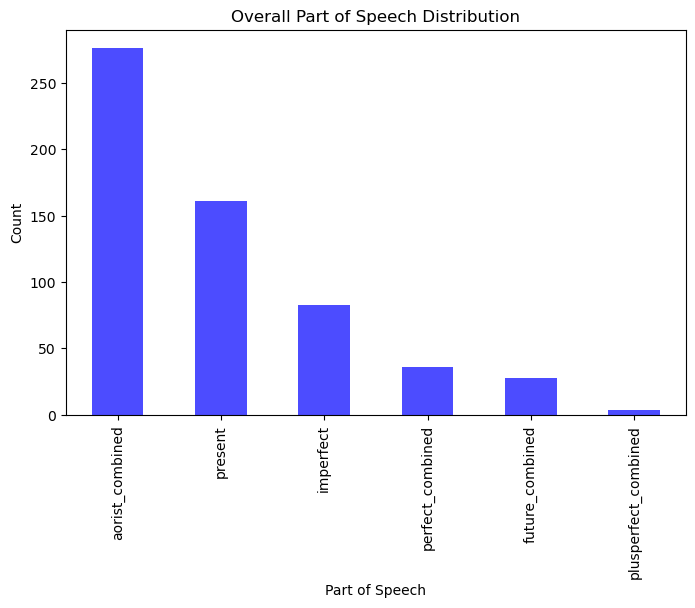

In [141]:
tense_counts= Healing['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Part of Speech Distribution')
plt.xlabel('Part of Speech')
plt.ylabel('Count')
plt.show()

Clearly the two most dominant tenses in all healing episodes are the Present Tense and the Aorist Tense. However, are these two tenses evenly distributed over the different gospel versions?

In [142]:
HealingMatthew=Healing[(Healing["book1"].str.contains('Mat')) & (Healing["AlandSynopEvent2"].str.contains('Heal')) & (Healing["bol_mood2"].str.contains('indicative'))]
HealingMark=Healing[(Healing["book1"].str.contains('Mark')) & (Healing["AlandSynopEvent2"].str.contains('Heal')) & (Healing["bol_mood2"].str.contains('indicative'))]
HealingLuke=Healing[(Healing["book1"].str.contains('Lu')) & (Healing["AlandSynopEvent2"].str.contains('Heal')) & (Healing["bol_mood2"].str.contains('indicative'))]
HealingJohn=Healing[(Healing["book1"].str.contains('Joh')) & (Healing["AlandSynopEvent2"].str.contains('Heal')) & (Healing["bol_mood2"].str.contains('indicative'))]


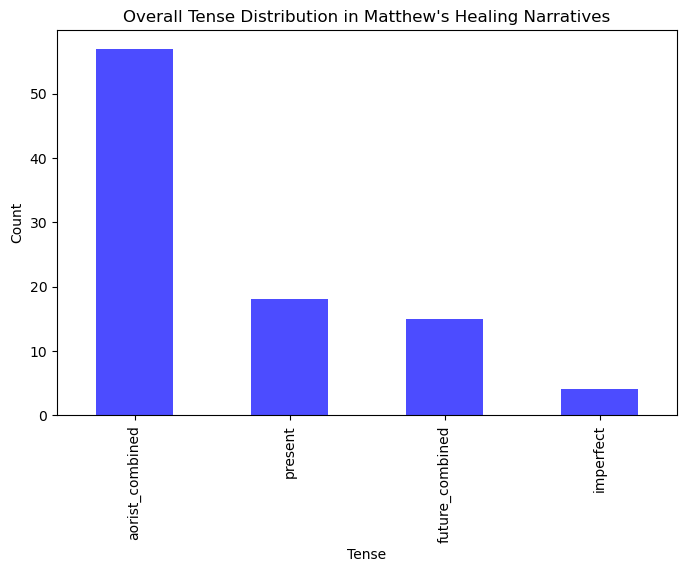

In [143]:
tense_counts= HealingMatthew['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution in Matthew\'s Healing Narratives')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

In Matthew the most dominent tense is the Aorist tense. This is particularly true if we take both 

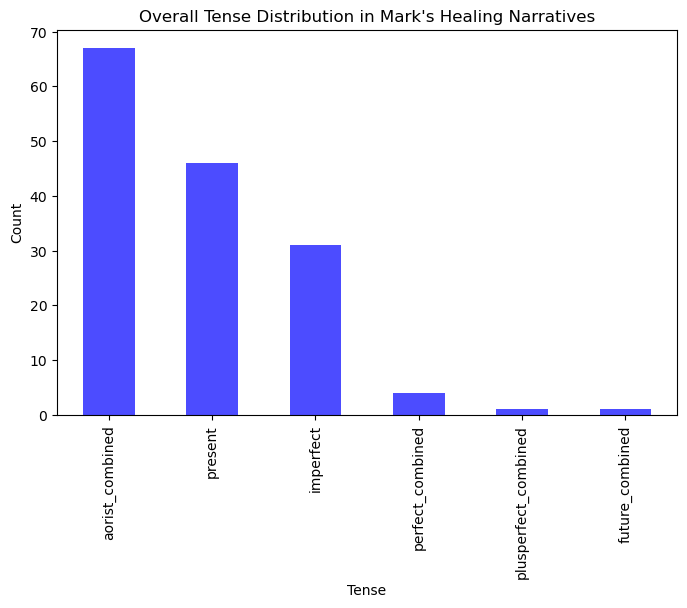

In [144]:
tense_counts= HealingMark['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution in Mark\'s Healing Narratives')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

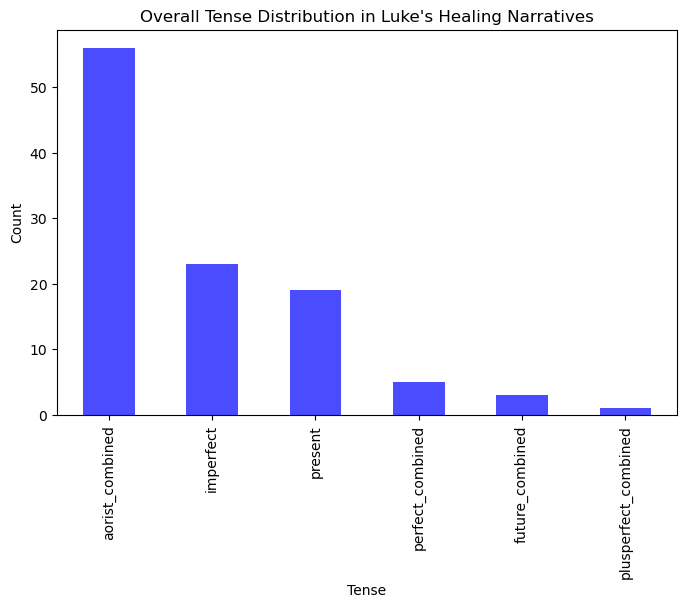

In [145]:
tense_counts= HealingLuke['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution in Luke\'s Healing Narratives')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

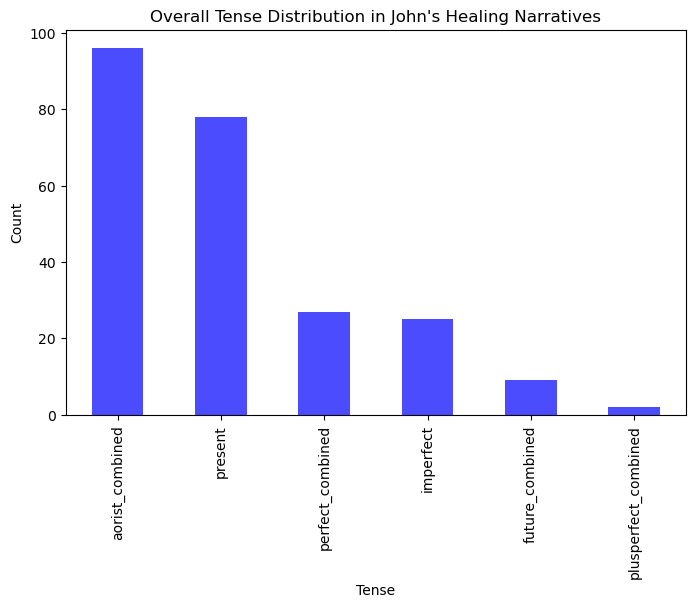

In [146]:
tense_counts= HealingJohn['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution in John\'s Healing Narratives')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

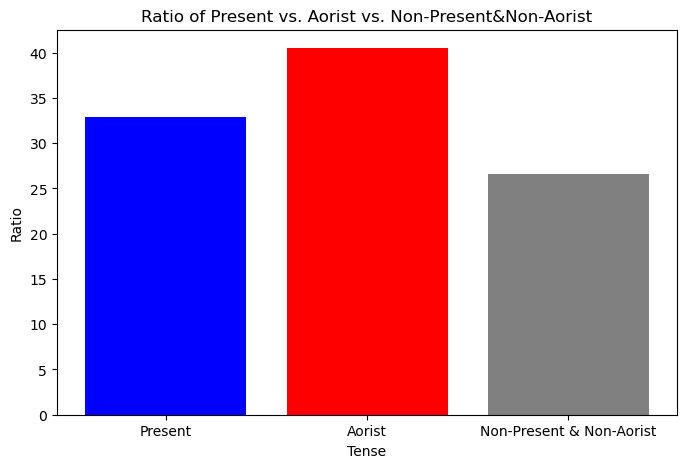

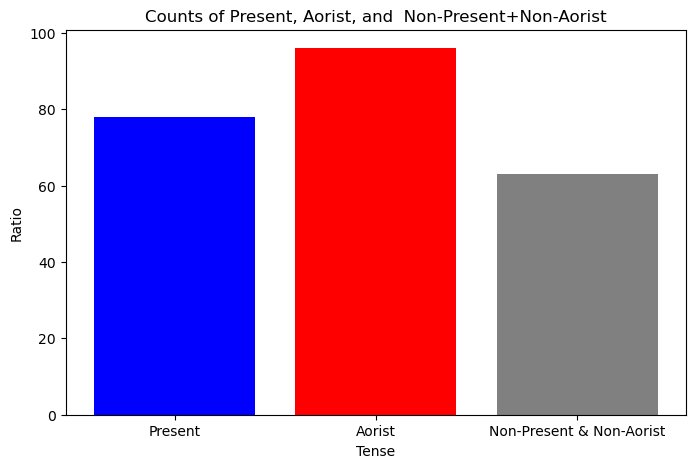

In [147]:
# Calculate the ratio of verbs to all non-verb entries
present_count = HealingJohn[HealingJohn['combitense'] == 'present'].shape[0]
non_presentORaorist_count = HealingJohn[  (HealingJohn['combitense'] == 'future_combined')
                                        + (HealingJohn['combitense'] == 'perfect_combined')
                                        + (HealingJohn['combitense'] == 'plusperfect_combined')
                                        + (HealingJohn['combitense'] == 'imperfect')].shape[0]
aorist_count = HealingJohn[HealingJohn['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present&Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and  Non-Present+Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()

In [148]:
print(presenttense, aoristtense, nopresentaoristtense)

32.91139240506329 40.50632911392405 26.582278481012658


In [149]:
HealingJohn[HealingJohn['combitense'] == 'present'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
ἔχω,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
δύναμαι,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
ἔρχομαι,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
θέλω,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
βλέπω,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
πιστεύω,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ποιέω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
λαμβάνω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3


In [150]:
HealingJohn[HealingJohn['combitense'] == 'aorist_combined'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24
ἀποκρίνομαι,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
ἀνοίγω,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
ἀκούω,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ἔρχομαι,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ποιέω,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
γεννάω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
ἐρωτάω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
ἀπέρχομαι,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3


In [151]:
pd.set_option('display.max_rows', None)
HealingJohn[HealingJohn['combitense'] == 'imperfect'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
πιστεύω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
διώκω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
δύναμαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ζητέω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
καταβαίνω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
κατάκειμαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
κατέχω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
λύω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


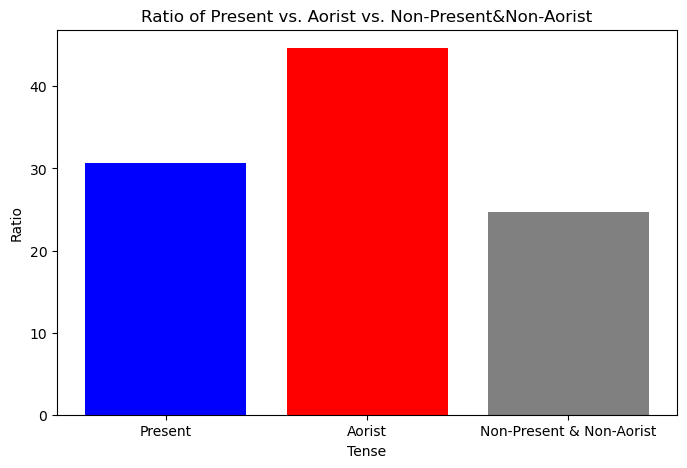

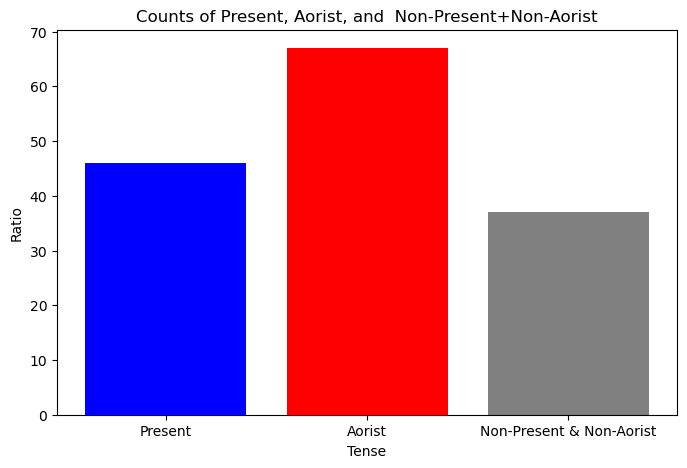

In [152]:
# Calculate the ratio of verbs to all non-verb entries
present_count = HealingMark[HealingMark['combitense'] == 'present'].shape[0]
non_presentORaorist_count = HealingMark[  (HealingMark['combitense'] == 'future_combined')
                                        + (HealingMark['combitense'] == 'perfect_combined')
                                        + (HealingMark['combitense'] == 'plusperfect_combined')
                                        + (HealingMark['combitense'] == 'imperfect')].shape[0]
aorist_count = HealingMark[HealingMark['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present&Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and  Non-Present+Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()

In [153]:
HealingMark[HealingMark['combitense'] == 'present'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
δύναμαι,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ἔρχομαι,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
βλέπω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
διαλογίζομαι,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
εἰμί,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
φέρω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
φωνέω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἀφίημι,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [154]:
pd.set_option('display.max_rows', None)
HealingMark[HealingMark['combitense'] == 'aorist_combined'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
ἔρχομαι,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
ἐξέρχομαι,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ἐγείρω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
βάλλω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
φέρω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἐπιτιμάω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἐπερωτάω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἅπτω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [155]:
pd.set_option('display.max_rows', None)
HealingMark[HealingMark['combitense'] == 'imperfect'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
ἐπιτιμάω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἐπερωτάω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
κατάκειμαι,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
κράζω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
λαλέω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
λέγω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
διακονέω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
φέρω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐμβλέπω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


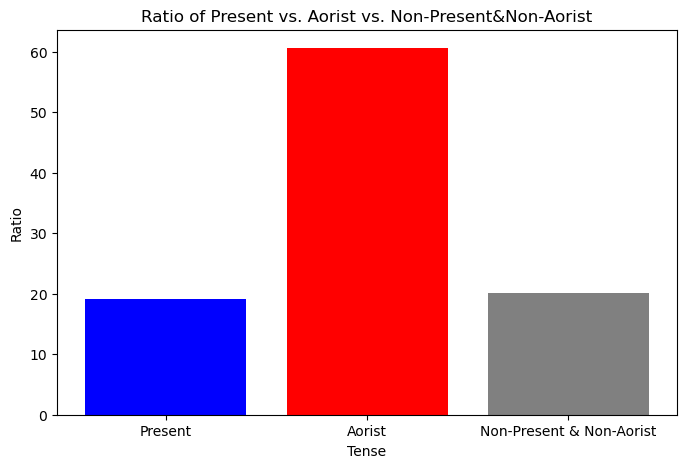

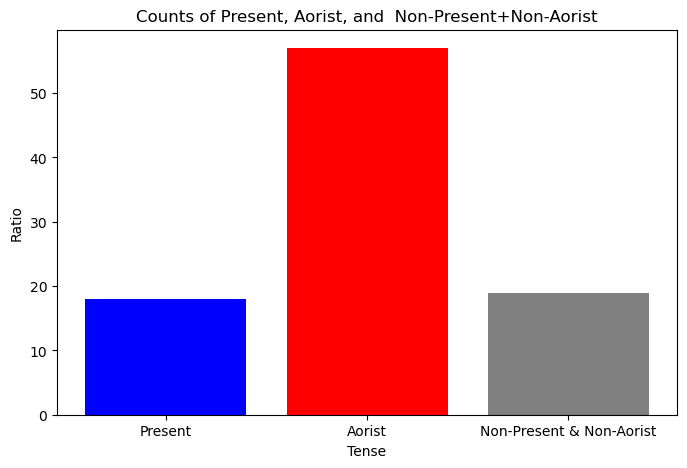

In [156]:
# Calculate the ratio of verbs to all non-verb entries
present_count = HealingMatthew[HealingMatthew['combitense'] == 'present'].shape[0]
non_presentORaorist_count = HealingMatthew[  (HealingMatthew['combitense'] == 'future_combined')
                                        + (HealingMatthew['combitense'] == 'perfect_combined')
                                        + (HealingMatthew['combitense'] == 'plusperfect_combined')
                                        + (HealingMatthew['combitense'] == 'imperfect')].shape[0]
aorist_count = HealingMatthew[HealingMatthew['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present&Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and  Non-Present+Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()

In [157]:
HealingMatthew[HealingMatthew['combitense'] == 'present'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
ἀφίημι,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἔξεστι(ν),2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἔχω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
βλασφημέω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
διαφέρω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
θέλω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
παράγω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
πίπτω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [158]:
HealingMatthew[HealingMatthew['combitense'] == 'aorist_combined'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
ἔρχομαι,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
θεραπεύω,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ἐπιτιμάω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
ἀκολουθέω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
προσφέρω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
ἅπτω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
δύναμαι,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
κράζω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [159]:
pd.set_option('display.max_rows', None)
HealingMatthew[HealingMatthew['combitense'] == 'imperfect'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
διακονέω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
κάθημαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
παρακαλέω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
προσφέρω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


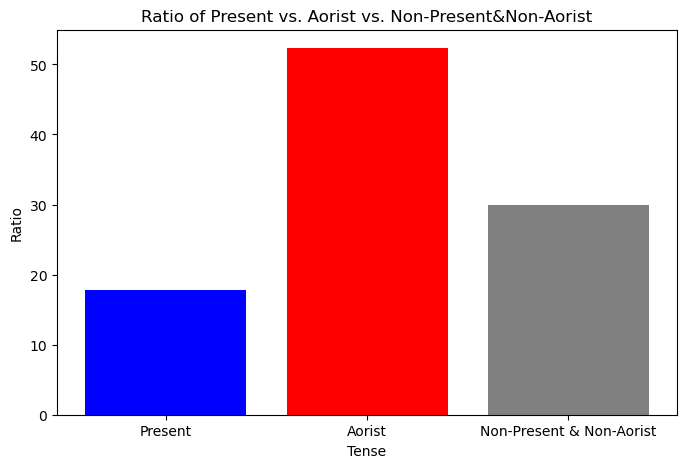

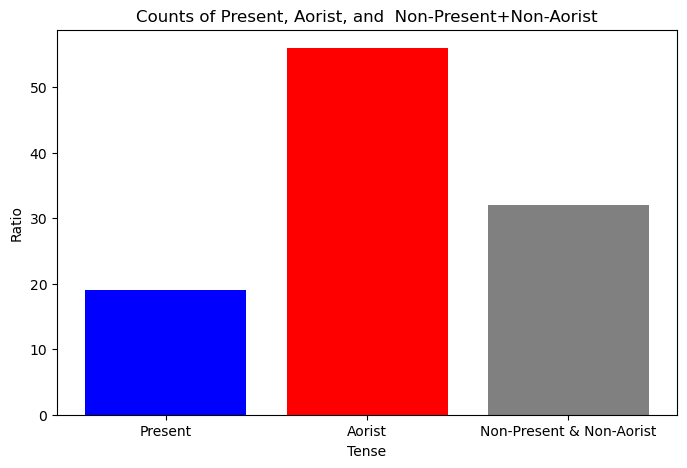

In [160]:
# Calculate the ratio of verbs to all non-verb entries
present_count = HealingLuke[HealingLuke['combitense'] == 'present'].shape[0]
non_presentORaorist_count = HealingLuke[  (HealingLuke['combitense'] == 'future_combined')
                                        + (HealingLuke['combitense'] == 'perfect_combined')
                                        + (HealingLuke['combitense'] == 'plusperfect_combined')
                                        + (HealingLuke['combitense'] == 'imperfect')].shape[0]
aorist_count = HealingLuke[HealingLuke['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present&Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and  Non-Present+Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()

In [161]:
HealingLuke[HealingLuke['combitense'] == 'present'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
δεῖ,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
λύω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἔξεστι(ν),1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐπιτάσσω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐξέρχομαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἀποχωρέω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
σπαράσσω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ποτίζω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
παρέρχομαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [162]:
pd.set_option('display.max_rows', None)

HealingLuke[HealingLuke['combitense'] == 'aorist_combined'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
γίνομαι,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
ἐπιτιμάω,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
βοάω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἰάομαι,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
ἰσχύω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἡσυχάζω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἔρχομαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐρωτάω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [163]:
pd.set_option('display.max_rows', None)
HealingLuke[HealingLuke['combitense'] == 'imperfect'].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False))

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
δοξάζω,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
δεῖ,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
πυνθάνομαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐάω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐπιτιμάω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐξέρχομαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐκπορεύομαι,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἐκπλήσσω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
ἀκολουθέω,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [164]:
print(presenttense, aoristtense, nopresentaoristtense)

17.757009345794394 52.33644859813084 29.906542056074766


##### Preliminary conclusions
The distributional analysis of the synoptic healing episodes in the different gospel accounts clearly show, that on the one side Matthew and Luke have a similar use of tenses with the Aorist tense being used dominantly while on the other side John and Mark use the present tense significantly more with John using both tenses in almost the same ration.

For several reasons, the comparison between Matthew and Mark suggests itself. First both gosples are historically and genetically much closer to each other. Second in contrast to the gospel of John, Matthew and Mark contains a significant amount of synoptic materials inviting for a comparative study of their different uses of the tenses.

#### Ratio calculations for Parable episodes

In [165]:
SynopSelection["AlandSynopEvent2"].unique()

array(['The Genealogy of Jesus', 'The Birth of Jesus',
       'The Adoration of the Infant Jesus',
       'The Flight into Egypt and Return',
       'The Childhood of Jesus at Nazareth', 'John the Baptist',
       'John’s Preaching of Repentance', 'John’s Messianic Preaching',
       'The Baptism of Jesus', 'The Temptation',
       'The Journey into Galilee', 'Ministry in Galilee',
       'The Call of the Disciples', 'First Preaching Tour in Galilee',
       'The Beatitudes', 'The Salt of the Earth',
       'The Light of the World', 'On the Law and the Prophets',
       'On Murder and Wrath', 'On Adultery and Divorce', 'On Oaths',
       'On Retaliation', 'On Love of One’s Enemies', 'On Almsgiving',
       'On Prayer', 'The Lord’s Prayer', 'On Fasting', 'On Treasures',
       'On Serving Two Masters', 'On Anxiety', 'On Judging',
       'On Profaning the Holy', 'God’s Answering of Prayer',
       'The Golden Rule', 'The Two Ways', '“By their Fruits”',
       '“Saying Lord, Lord”', 'The 

In [166]:
ParableMatthew=SynopSelection[(SynopSelection["book1"].str.contains('Mat')) & (SynopSelection["AlandSynopEvent2"].str.contains('.*Parab'))]
ParableMark=SynopSelection[(SynopSelection["book1"].str.contains('Mark')) & (SynopSelection["AlandSynopEvent2"].str.contains('Parab'))]
ParableLuke=SynopSelection[(SynopSelection["book1"].str.contains('Lu')) & (SynopSelection["AlandSynopEvent2"].str.contains('Parab'))]
ParableJohn=SynopSelection[(SynopSelection["book1"].str.contains('Joh')) & (SynopSelection["AlandSynopEvent2"].str.contains('Parab'))]
ParableJohn.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense


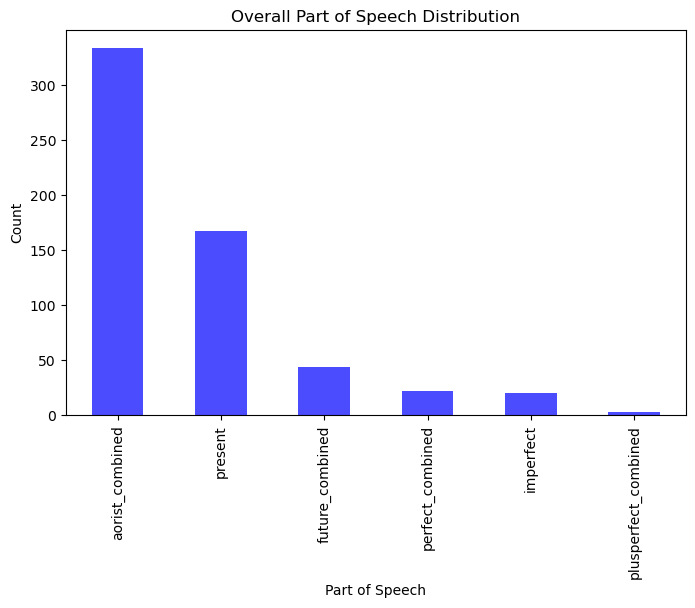

In [167]:
tense_counts= ParableMatthew['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Part of Speech Distribution')
plt.xlabel('Part of Speech')
plt.ylabel('Count')
plt.show()

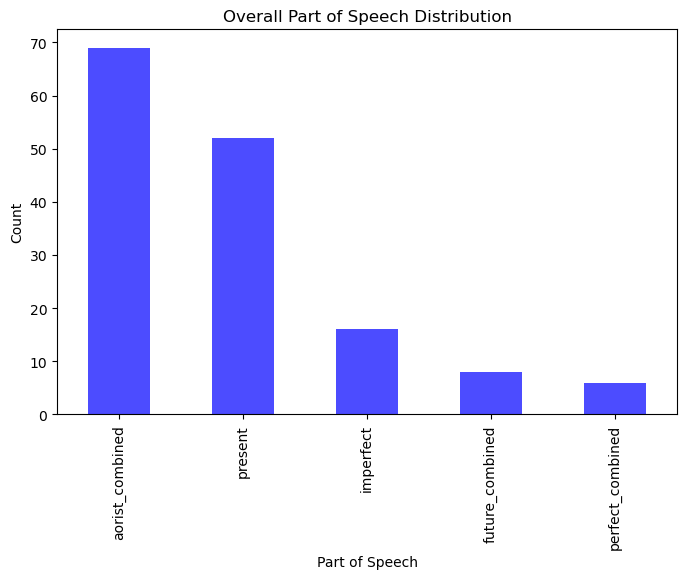

In [168]:
tense_counts= ParableMark['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Part of Speech Distribution')
plt.xlabel('Part of Speech')
plt.ylabel('Count')
plt.show()

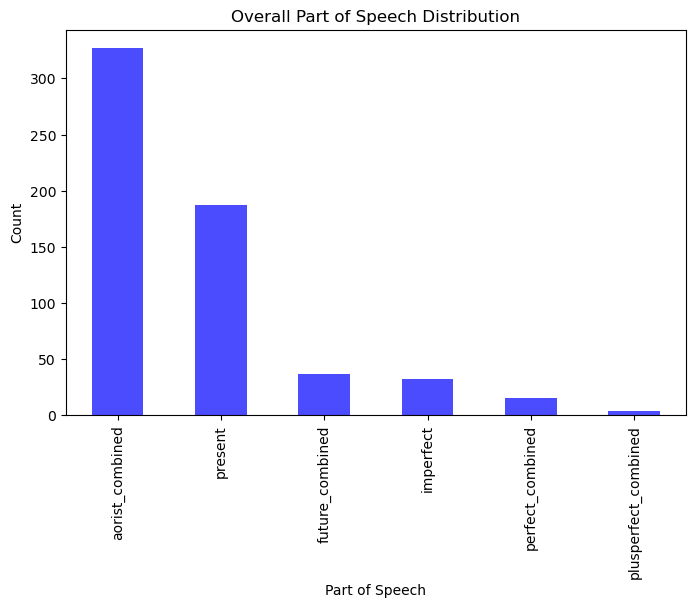

In [169]:
tense_counts= ParableLuke['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Part of Speech Distribution')
plt.xlabel('Part of Speech')
plt.ylabel('Count')
plt.show()

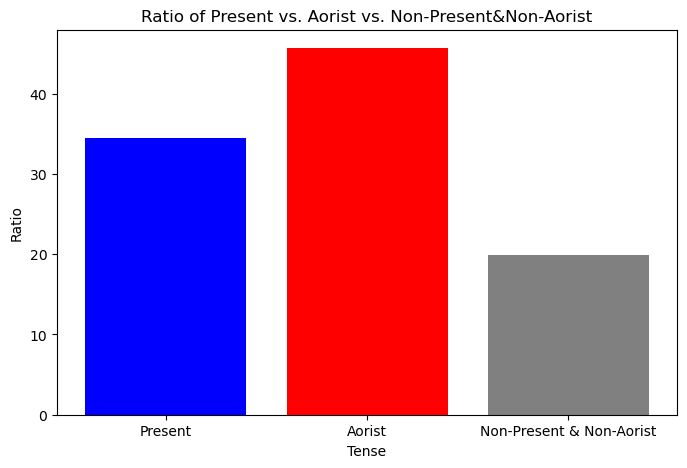

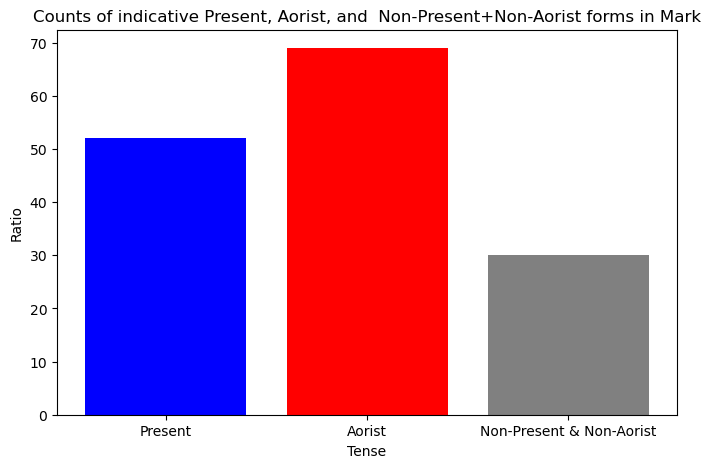

In [170]:
# Calculate the ratio of verbs to all non-verb entries
present_count = ParableMark[ParableMark['combitense'] == 'present'].shape[0]
non_presentORaorist_count = ParableMark[  (ParableMark['combitense'] == 'future_combined')
                                        + (ParableMark['combitense'] == 'perfect_combined')
                                        + (ParableMark['combitense'] == 'plusperfect_combined')
                                        + (ParableMark['combitense'] == 'imperfect')].shape[0]
aorist_count = ParableMark[ParableMark['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present&Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of indicative Present, Aorist, and  Non-Present+Non-Aorist forms in Mark')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()

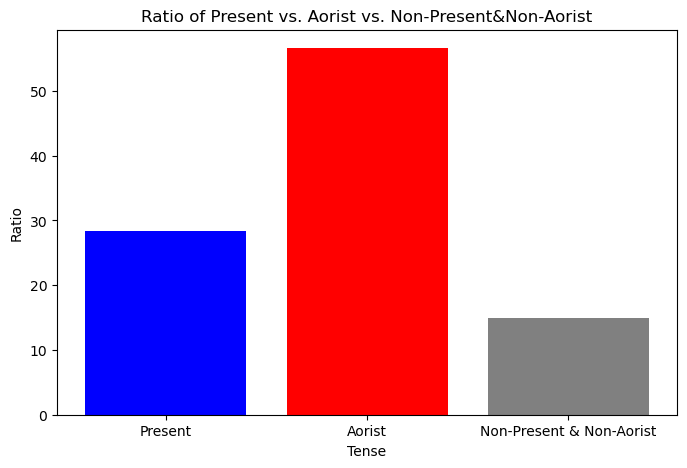

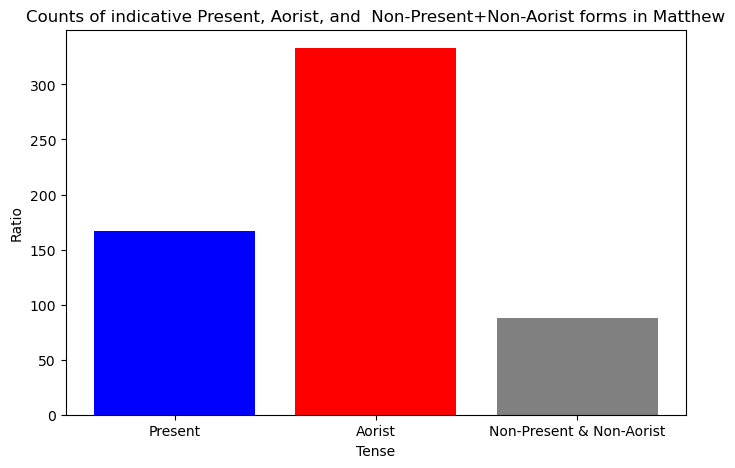

In [171]:
# Calculate the ratio of verbs to all non-verb entries
present_count = ParableMatthew[ParableMatthew['combitense'] == 'present'].shape[0]
non_presentORaorist_count = ParableMatthew[  (ParableMatthew['combitense'] == 'future_combined')
                                        + (ParableMatthew['combitense'] == 'perfect_combined')
                                        + (ParableMatthew['combitense'] == 'plusperfect_combined')
                                        + (ParableMatthew['combitense'] == 'imperfect')].shape[0]
aorist_count = ParableMatthew[ParableMatthew['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present&Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of indicative Present, Aorist, and  Non-Present+Non-Aorist forms in Matthew')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()

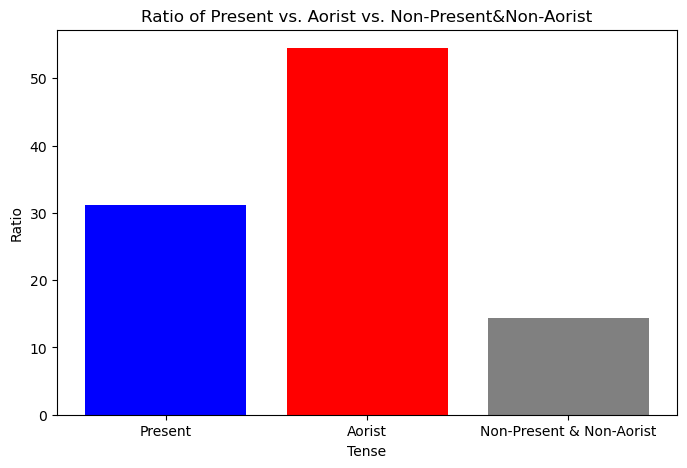

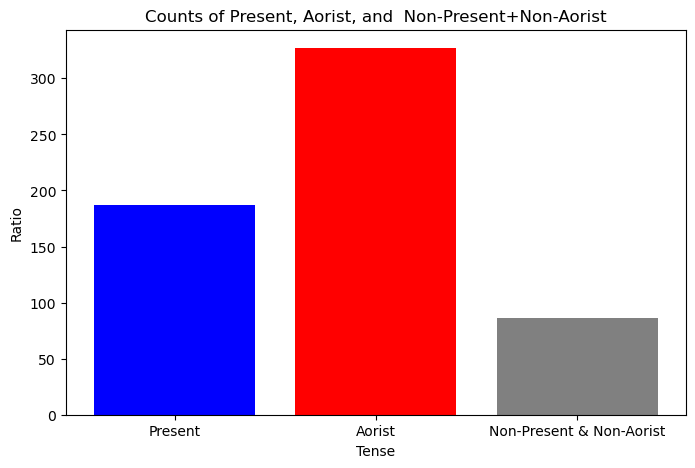

In [172]:
# Calculate the ratio of verbs to all non-verb entries
present_count = ParableLuke[ParableLuke['combitense'] == 'present'].shape[0]
non_presentORaorist_count = ParableLuke[  (ParableLuke['combitense'] == 'future_combined')
                                        + (ParableLuke['combitense'] == 'perfect_combined')
                                        + (ParableLuke['combitense'] == 'plusperfect_combined')
                                        + (ParableLuke['combitense'] == 'imperfect')].shape[0]
aorist_count = ParableLuke[ParableLuke['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present&Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and  Non-Present+Non-Aorist')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.show()

In [173]:
print(presenttense, aoristtense, nopresentaoristtense)

31.166666666666664 54.5 14.333333333333332


##### Preliminary conclusions
The distributional analysis of the synoptic healing episodes in the different gospel accounts clearly show, that on the one side Matthew and Luke have a similar use of tenses with the Aorist tense being used dominantly while on the other side John and Mark use the present tense significantly more with John using both tenses in almost the same ration.

For several reasons, the comparison between Matthew and Mark suggests itself. First both gosples are historically and genetically much closer to each other. Second in contrast to the gospel of John, Matthew and Mark contains a significant amount of synoptic materials inviting for a comparative study of their different uses of the tenses.

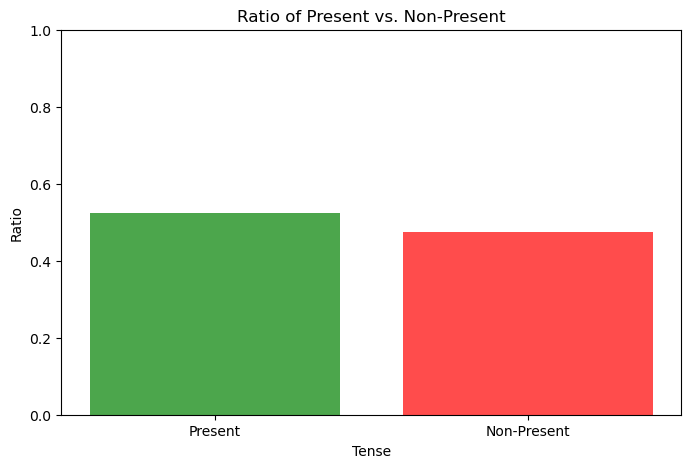

In [174]:
# Calculate the ratio of verbs to all non-verb entries
present_count = ParableMark[ParableMark['combitense'] == 'present'].shape[0]
non_present_count = ParableMark[ParableMark['combitense'] != 'present'].shape[0]
tense_ratio = present_count / non_present_count

# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Non-Present'], [tense_ratio, 1 - tense_ratio], color=['green', 'red'], alpha=0.7)
plt.title('Ratio of Present vs. Non-Present')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.ylim(0, 1)  # Set y-axis limits to ensure the ratio is between 0 and 1
plt.show()

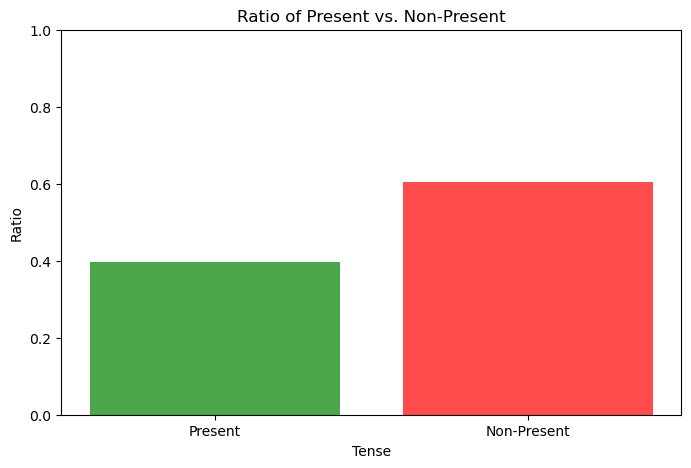

In [175]:
# Calculate the ratio of verbs to all non-verb entries
present_count = ParableMatthew[ParableMatthew['combitense'] == 'present'].shape[0]
non_present_count = ParableMatthew[ParableMatthew['combitense'] != 'present'].shape[0]
tense_ratio = present_count / non_present_count

# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Non-Present'], [tense_ratio, 1 - tense_ratio], color=['green', 'red'], alpha=0.7)
plt.title('Ratio of Present vs. Non-Present')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.ylim(0, 1)  # Set y-axis limits to ensure the ratio is between 0 and 1
plt.show()

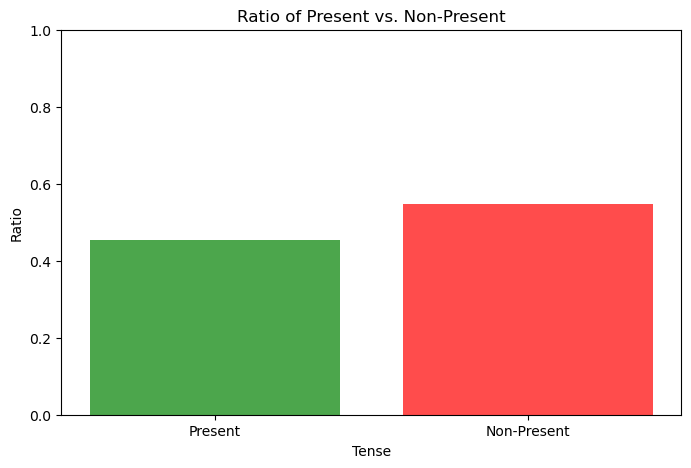

In [176]:
# Calculate the ratio of verbs to all non-verb entries
present_count = ParableLuke[ParableLuke['bol_tense2'] == 'present'].shape[0]
non_present_count = ParableLuke[ParableLuke['bol_tense2'] != 'present'].shape[0]
tense_ratio = present_count / non_present_count

# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Non-Present'], [tense_ratio, 1 - tense_ratio], color=['green', 'red'], alpha=0.7)
plt.title('Ratio of Present vs. Non-Present')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.ylim(0, 1)  # Set y-axis limits to ensure the ratio is between 0 and 1
plt.show()

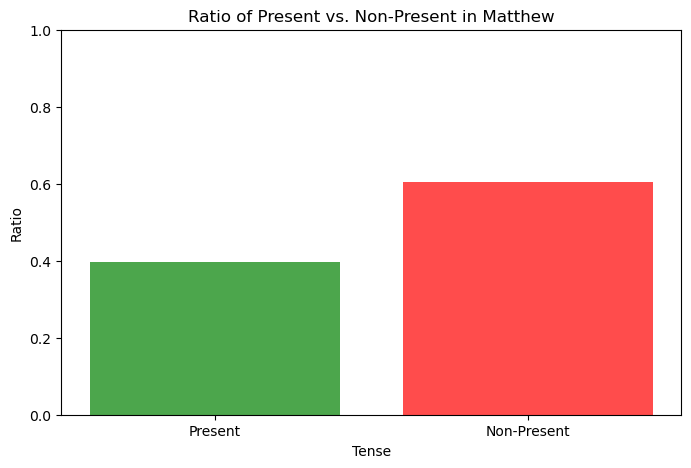

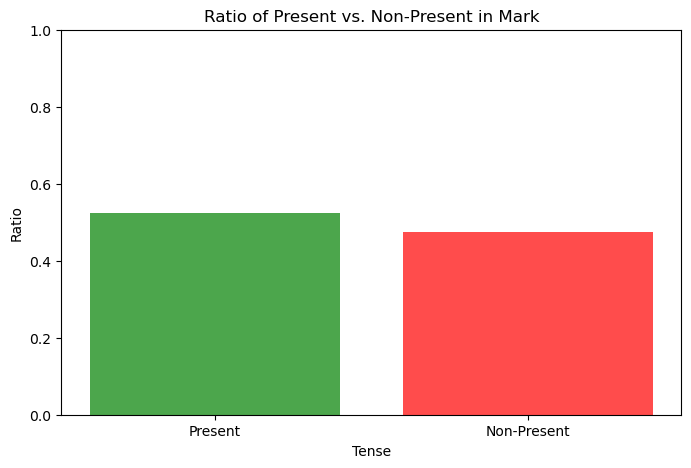

In [177]:
# Calculate the ratio of verbs to all non-verb entries
present_countMat = ParableMatthew[ParableMatthew['bol_tense2'] == 'present'].shape[0]
non_present_countMat = ParableMatthew[ParableMatthew['bol_tense2'] != 'present'].shape[0]
tense_ratioMat = present_countMat / non_present_countMat

# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Non-Present'], [tense_ratioMat, 1 - tense_ratioMat], color=['green', 'red'], alpha=0.7)
plt.title('Ratio of Present vs. Non-Present in Matthew')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.ylim(0, 1)  # Set y-axis limits to ensure the ratio is between 0 and 1
plt.show()

# Calculate the ratio of verbs to all non-verb entries
present_countMk = ParableMark[ParableMark['bol_tense2'] == 'present'].shape[0]
non_present_countMk = ParableMark[ParableMark['bol_tense2'] != 'present'].shape[0]
tense_ratioMk = present_countMk / non_present_countMk

# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Non-Present'], [tense_ratioMk, 1 - tense_ratioMk], color=['green', 'red'], alpha=0.7)
plt.title('Ratio of Present vs. Non-Present in Mark')
plt.xlabel('Tense')
plt.ylabel('Ratio')
plt.ylim(0, 1)  # Set y-axis limits to ensure the ratio is between 0 and 1
plt.show()

#### Ratio calculations for Narration episodes

In [178]:
SynopSelection["AlandSynopChapter2"].unique()

array(['Birth and Childhood', 'Preparation', 'Jesus’ Ministry in Galilee',
       'The Sermon on the Mount (According to Matthew)',
       'Jesus’ Ministry in Galilee Continued', 'The Way to the Cross',
       'The Ministry in Judea', 'The Final Ministry in Jerusalem',
       'The Eschatological Discourse',
       'Conclusion of the Account of the time before the Passion',
       'The Passion Narrative', 'The Resurrection',
       'The Endings of the Gospels',
       'The Sermon on the Plain (According to Luke)',
       'Last Journey to Jerusalem (According to Luke)',
       'The Beginning of Jesus’ Public Ministry (According to John)',
       'Jesus at the Feast of Tabernacles (According to John)'],
      dtype=object)

In [179]:
PassionNarrativeMatthew=SynopSelection[(SynopSelection["book1"].str.contains('Mat')) & (SynopSelection["AlandSynopChapter2"].str.contains('Narra')) & (SynopSelection["bol_mood2"].str.contains('indicative'))]
PassionNarrativeMark=SynopSelection[(SynopSelection["book1"].str.contains('Mark')) & (SynopSelection["AlandSynopChapter2"].str.contains('Narra')) & (SynopSelection["bol_mood2"].str.contains('indicative'))]
PassionNarrativeLuke=SynopSelection[(SynopSelection["book1"].str.contains('Lu')) & (SynopSelection["AlandSynopChapter2"].str.contains('Narra')) & (SynopSelection["bol_mood2"].str.contains('indicative'))]
PassionNarrativeJohn=SynopSelection[(SynopSelection["book1"].str.contains('Joh')) & (SynopSelection["AlandSynopChapter2"].str.contains('Narra')) & (SynopSelection["bol_mood2"].str.contains('indicative'))]
PassionNarrativeJohn.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
11985,11986,John,13,1,386191,verse,Πρὸ δὲ τῆς ἑορτῆς τοῦ πάσχα εἰδὼς ὁ Ἰησοῦς ὅτι...,John,13,1,59110,word,ἦλθεν,The Passion Narrative,Washing the Disciples’ Feet,309.0,ἔρχομαι,59110,indicative,second_aorist,active,Pred,erkhomai,verb,aorist_combined
11988,11989,John,13,1,386191,verse,Πρὸ δὲ τῆς ἑορτῆς τοῦ πάσχα εἰδὼς ὁ Ἰησοῦς ὅτι...,John,13,1,59132,word,ἠγάπησεν,The Passion Narrative,Washing the Disciples’ Feet,309.0,ἀγαπάω,59132,indicative,aorist,active,Pred,agapao,verb,aorist_combined
11993,11994,John,13,3,386193,verse,εἰδὼς ὅτι πάντα ἔδωκεν αὐτῷ ὁ Πατὴρ εἰς τὰς χε...,John,13,3,59153,word,ἔδωκεν,The Passion Narrative,Washing the Disciples’ Feet,309.0,δίδωμι,59153,indicative,aorist,active,Pred,didomi,verb,aorist_combined
11994,11995,John,13,3,386193,verse,εἰδὼς ὅτι πάντα ἔδωκεν αὐτῷ ὁ Πατὴρ εἰς τὰς χε...,John,13,3,59164,word,ἐξῆλθεν,The Passion Narrative,Washing the Disciples’ Feet,309.0,ἐξέρχομαι,59164,indicative,second_aorist,active,Pred,exerkhomai,verb,aorist_combined
11995,11996,John,13,3,386193,verse,εἰδὼς ὅτι πάντα ἔδωκεν αὐτῷ ὁ Πατὴρ εἰς τὰς χε...,John,13,3,59169,word,"ὑπάγει,",The Passion Narrative,Washing the Disciples’ Feet,309.0,ὑπάγω,59169,indicative,present,active,Pred,upago,verb,present


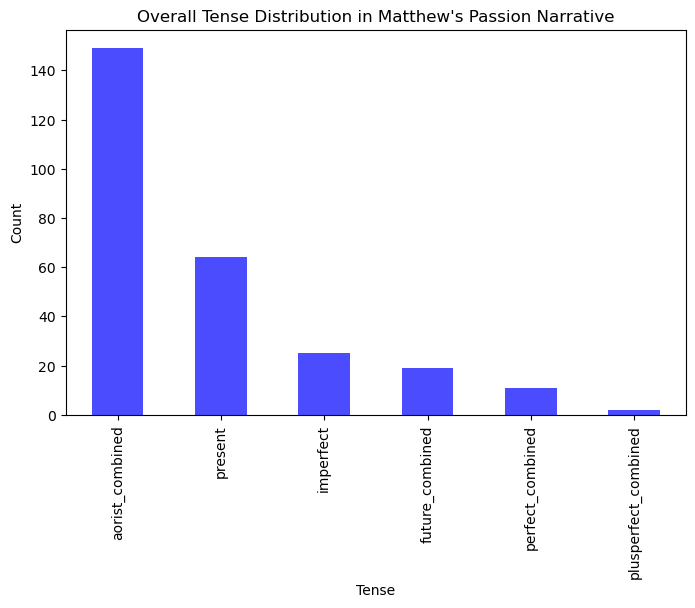

In [180]:
tense_counts= PassionNarrativeMatthew['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution in Matthew\'s Passion Narrative')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

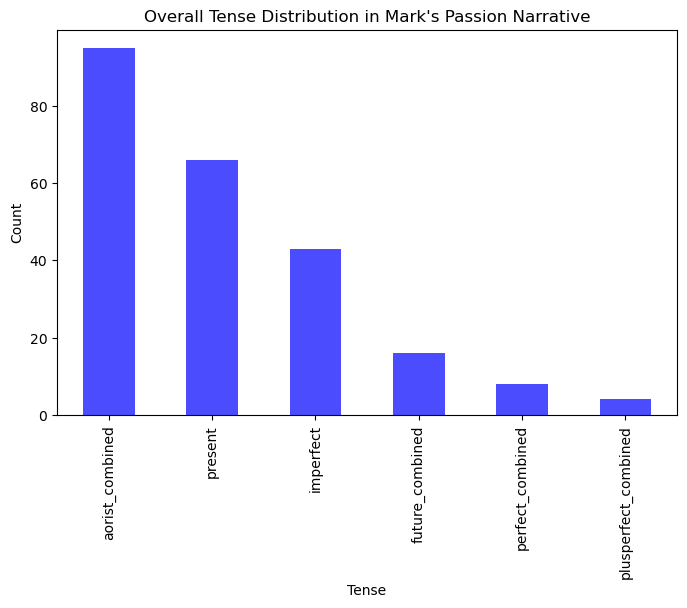

In [181]:
tense_counts= PassionNarrativeMark['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Tense Distribution in Mark\'s Passion Narrative')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

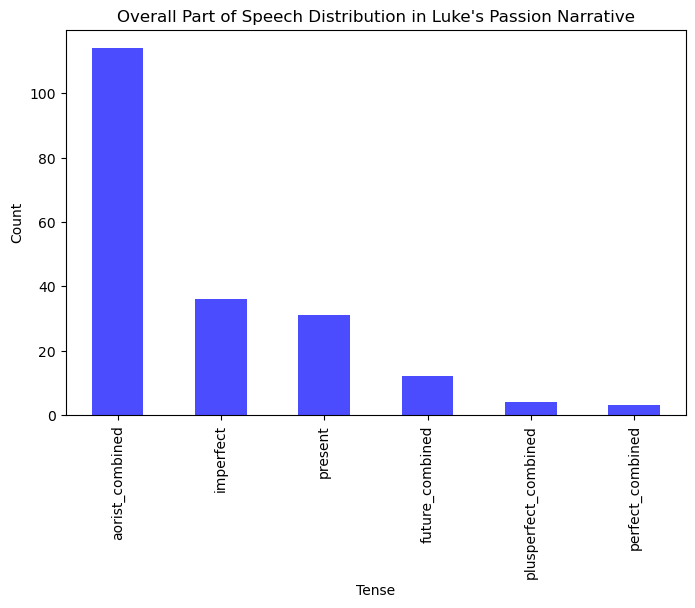

In [182]:
tense_counts= PassionNarrativeLuke['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Part of Speech Distribution in Luke\'s Passion Narrative')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

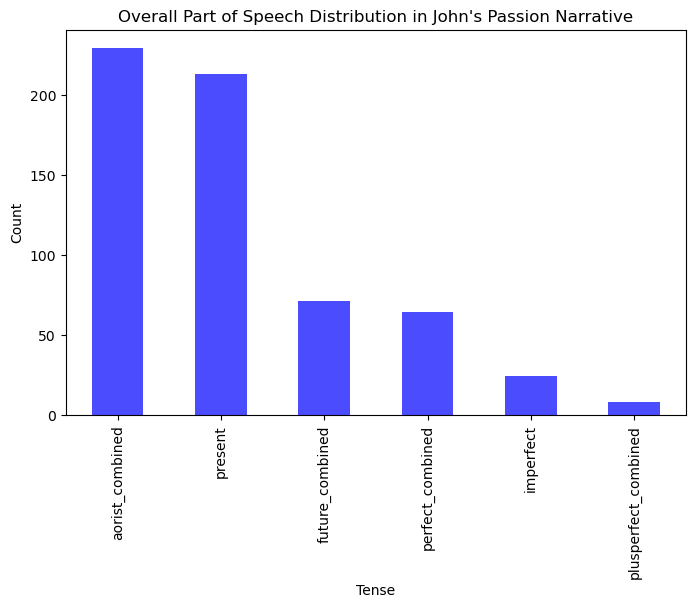

In [183]:
tense_counts= PassionNarrativeJohn['combitense'].value_counts()
# Plotting the overall distribution
plt.figure(figsize=(8, 5))
tense_counts.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Overall Part of Speech Distribution in John\'s Passion Narrative')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

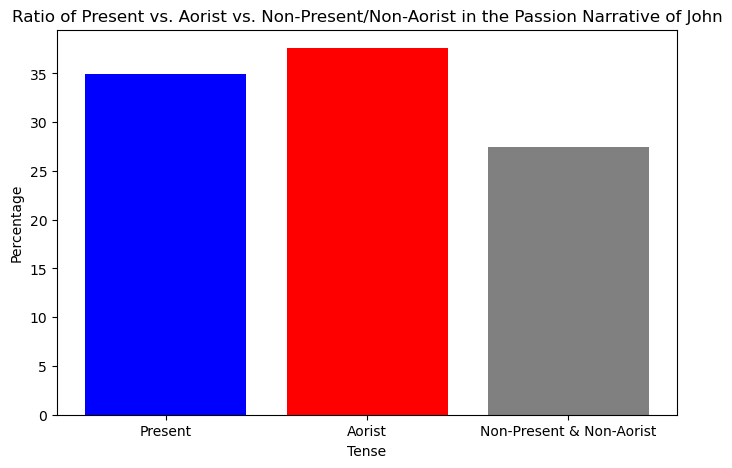

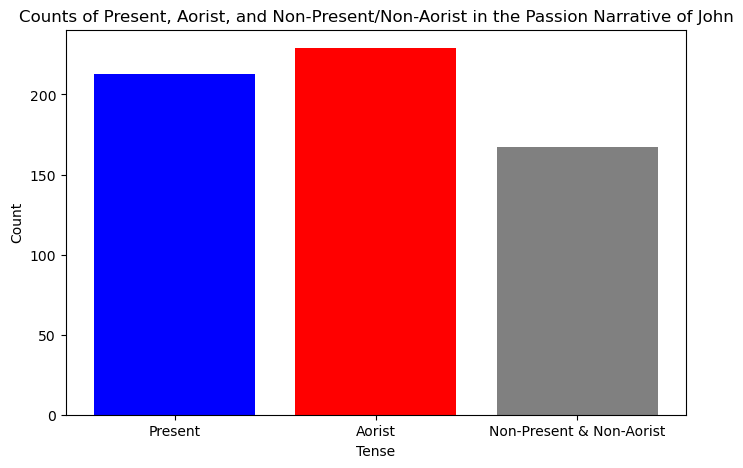

In [184]:
# Calculate the ratio of verbs to all non-verb entries
present_count = PassionNarrativeJohn[PassionNarrativeJohn['combitense'] == 'present'].shape[0]
non_presentORaorist_count = PassionNarrativeJohn[  (PassionNarrativeJohn['combitense'] == 'future_combined')
                                        + (PassionNarrativeJohn['combitense'] == 'perfect_combined')
                                        + (PassionNarrativeJohn['combitense'] == 'plusperfect_combined')
                                        + (PassionNarrativeJohn['combitense'] == 'imperfect')].shape[0]
aorist_count = PassionNarrativeJohn[PassionNarrativeJohn['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present/Non-Aorist in the Passion Narrative of John')
plt.xlabel('Tense')
plt.ylabel('Percentage')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and Non-Present/Non-Aorist in the Passion Narrative of John')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

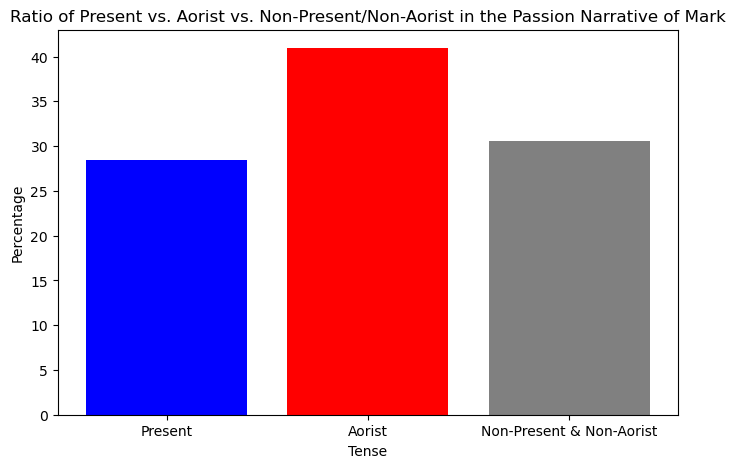

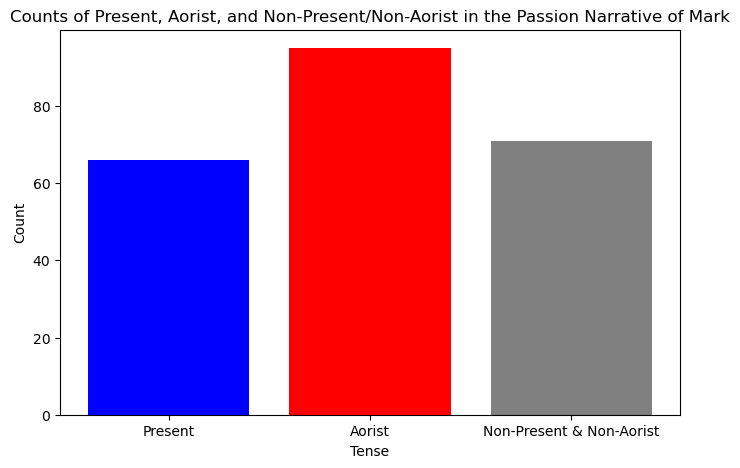

In [185]:
# Calculate the ratio of verbs to all non-verb entries
present_count = PassionNarrativeMark[PassionNarrativeMark['combitense'] == 'present'].shape[0]
non_presentORaorist_count = PassionNarrativeMark[  (PassionNarrativeMark['combitense'] == 'future_combined')
                                        + (PassionNarrativeMark['combitense'] == 'perfect_combined')
                                        + (PassionNarrativeMark['combitense'] == 'plusperfect_combined')
                                        + (PassionNarrativeMark['combitense'] == 'imperfect')].shape[0]
aorist_count = PassionNarrativeMark[PassionNarrativeMark['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present/Non-Aorist in the Passion Narrative of Mark')
plt.xlabel('Tense')
plt.ylabel('Percentage')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and Non-Present/Non-Aorist in the Passion Narrative of Mark')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

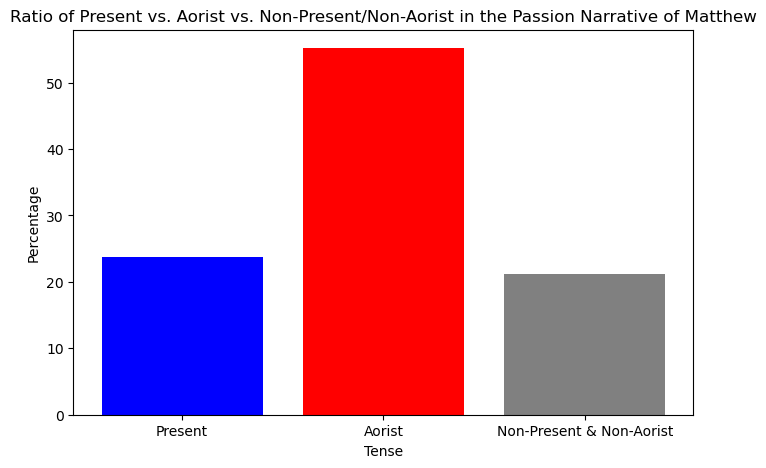

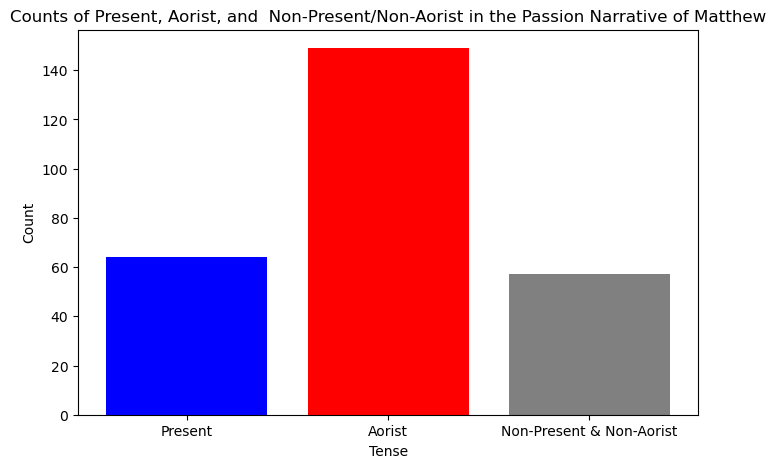

In [186]:
# Calculate the ratio of verbs to all non-verb entries
present_count = PassionNarrativeMatthew[PassionNarrativeMatthew['combitense'] == 'present'].shape[0]
non_presentORaorist_count = PassionNarrativeMatthew[  (PassionNarrativeMatthew['combitense'] == 'future_combined')
                                        + (PassionNarrativeMatthew['combitense'] == 'perfect_combined')
                                        + (PassionNarrativeMatthew['combitense'] == 'plusperfect_combined')
                                        + (PassionNarrativeMatthew['combitense'] == 'imperfect')].shape[0]
aorist_count = PassionNarrativeMatthew[PassionNarrativeMatthew['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present/Non-Aorist in the Passion Narrative of Matthew')
plt.xlabel('Tense')
plt.ylabel('Percentage')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and  Non-Present/Non-Aorist in the Passion Narrative of Matthew')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

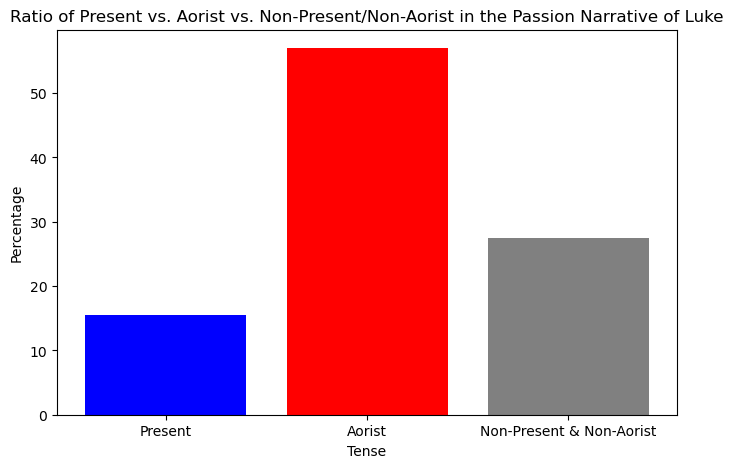

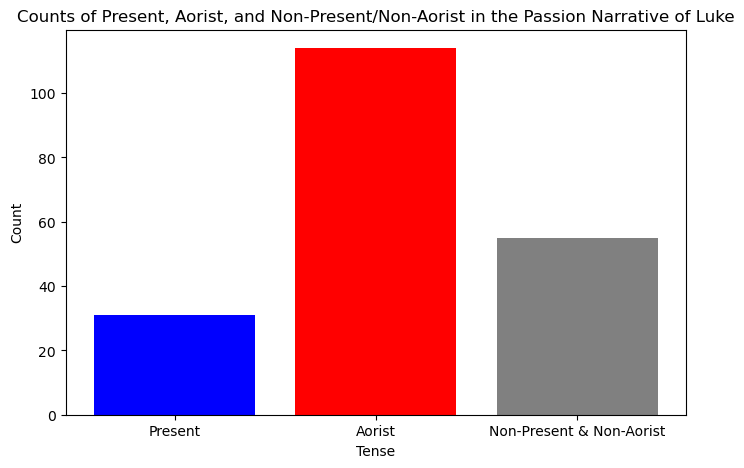

In [187]:
# Calculate the ratio of verbs to all non-verb entries
present_count = PassionNarrativeLuke[PassionNarrativeLuke['combitense'] == 'present'].shape[0]
non_presentORaorist_count = PassionNarrativeLuke[  (PassionNarrativeLuke['combitense'] == 'future_combined')
                                        + (PassionNarrativeLuke['combitense'] == 'perfect_combined')
                                        + (PassionNarrativeLuke['combitense'] == 'plusperfect_combined')
                                        + (PassionNarrativeLuke['combitense'] == 'imperfect')].shape[0]
aorist_count = PassionNarrativeLuke[PassionNarrativeLuke['combitense'] == 'aorist_combined'].shape[0]

presenttense = 100/(present_count+non_presentORaorist_count+aorist_count)*present_count
nopresentaoristtense = 100/(present_count+non_presentORaorist_count+aorist_count)*non_presentORaorist_count
aoristtense = 100/(aorist_count+present_count+non_presentORaorist_count)*aorist_count


# Plotting the ratio
plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [presenttense, aoristtense, nopresentaoristtense], color=['blue', 'red', 'grey'])
plt.title('Ratio of Present vs. Aorist vs. Non-Present/Non-Aorist in the Passion Narrative of Luke')
plt.xlabel('Tense')
plt.ylabel('Percentage')
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(['Present', 'Aorist', 'Non-Present & Non-Aorist'], [present_count, aorist_count, non_presentORaorist_count], color=['blue', 'red', 'grey'])
plt.title('Counts of Present, Aorist, and Non-Present/Non-Aorist in the Passion Narrative of Luke')
plt.xlabel('Tense')
plt.ylabel('Count')
plt.show()

#### Conclusion
We can see that when the gospels use the present tense in their healing narratives the all use most dominantly the word in present λέγω tense. Where they differ to what frequency they us also other verbs in present tense. In the gospel of Luke and Mark λέγω is by far the most dominantly used when they shooses for the present tense. In contrat to Luke and Mark, John selects the four verbs ἔχω (13x), λέγω (13x), βλέπω (10x), and ποιέω (12x) in comparable frequency in the present tense. While Mark prefers to use λέγω (18x) in the present tense he is uses this verb like no other so frequenly in present tense.
Mark's behavior becomes even more striken when we compare the ratio of his λέγω-use in present tense and his λέγω-use in aorist tense, with the other gospels. 

Mark uses λέγω in present tense 18x and in aorist tense only 11x. This ratio is reversed with the verb ἐξέρχομαι/ἔρχομαι/eisercomai in present tense (3) but in aorist tense (21x)

In contrast, Matthew and Luke distirbute their present and aorist tense use for λέγω pretty equally:
Matthew uses λέγω in present tense 11x and in aorist tense  9x. This ratio with the verb ἔρχομαι in present tense (0) but in aorist tense (6x)
Luke uses λέγω in present tense 10x and in aorist tense  13x (in imperfect tense 1x). This ratio is reversed with the verb ἐξέρχομαι/ἔρχομαι in present tense (2) but in aorist tense (4x)

John stands in opposition to Mark with a significant higher aorist use for λέγω than present tense use.
John uses λέγω in present tense 13x and in aorist tense  26x (in imperfect tense 10x). This ratio with the verb ἔρχομαι in present tense (5) but in aorist tense (6x)

The tense ratio analysis, the gospel comparison analysis and the comparison with are used lemmmas paints a clear picture:
Mark focuses distinctivly on the present tense use of verbs of speaking. Word of movment, and other action verbs are usually put in Aorist or non-present tenses. Words like λαλέω or  διαλογίζομαι do appear in present tense but not in Aorist tense (in imperfect tense lego is used 2x and laleo 2x).

To examplify our observations we are going to use TF to contrast our findings between Mark and other gospels.

In [189]:
SynopticTenseComp = '''
b1:verse book=Matthew chapter* verse*
     w1:word AlandSynopEvent~.*eali.* AlandSynopEventNr* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*
b2:verse book=Mark chapter* verse*
     w2:word AlandSynopEvent* AlandSynopEventNr* AlandSynopChapter* bol_lemma* sp=verb bol_tense=present function=Pred bol_voice* bol_monad_num* lemma_translit=lego


w1 .AlandSynopEvent=AlandSynopEvent. w2


w1 .bol_lemma=bol_lemma. w2
w1 .bol_tense#bol_tense. w2





'''
SynopticTenseComp = N1904.search(SynopticTenseComp)
N1904.table(SynopticTenseComp, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)

  0.29s 27 results


In [190]:
JohnMark = '''
b1:verse book=John chapter* verse*
     w1:word AlandSynopEvent* AlandSynopEventNr* AlandSynopChapter~.*assio.* bol_lemma* sp=verb bol_tense* bol_voice* bol_monad_num*
b2:verse book=Mark chapter* verse*
     w2:word AlandSynopEvent* AlandSynopEventNr* AlandSynopChapter* bol_lemma* sp=verb bol_tense=present bol_voice* bol_monad_num* lemma_translit=lego


w1 .AlandSynopEvent=AlandSynopEvent. w2


w1 .bol_lemma=bol_lemma. w2
w1 .bol_tense#bol_tense. w2

'''
JohnMark = N1904.search(JohnMark)
N1904.table(JohnMark, start=1, end=1, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)

  0.35s 81 results


n,p,verse,word
1,Mark 14:18,,λέγω


In [191]:
N1904.export(JohnMark, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research', toFile='JohnMark.tsv')

In [192]:
JesusSaying = '''
book book=John
 c1:clause
  p1:phrase function=Subj
          w1:word lemma_translit=Iesous AlandSynopEvent* AlandSynopEventNr* AlandSynopChapter* bol_lemma* bol_voice* bol_monad_num* bol_psp=noun
  p2:phrase function=Pred
          w2:word lemma_translit* AlandSynopEvent* AlandSynopEventNr* AlandSynopChapter* bol_lemma* bol_voice* bol_monad_num* bol_tense=present


c1  <parent- p1
c1  <parent- p2
'''
JesusSaying = N1904.search(JesusSaying)
N1904.table(JesusSaying, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={'wg'}, multiFeatures=False)

  0.39s 27 results


n,p,verse,word (+2),phrase (+2),word (+2),phrase (+2),phrase (+2)
1,John 1:29,,τὸν Ἰησοῦν,ἐρχόμενον,Ἰησοῦν,ἐρχόμενον,"τὸν Ἰησοῦν ἐρχόμενον πρὸς αὐτόν,"
2,John 1:36,,τῷ Ἰησοῦ περιπατοῦντι,Ἰησοῦ,περιπατοῦντι,τῷ Ἰησοῦ,περιπατοῦντι
3,John 1:38,,στραφεὶς ὁ Ἰησοῦς καὶ θεασάμενος αὐτοὺς ἀκολουθοῦντας λέγει αὐτοῖς Τί ζητεῖτε;,ὁ Ἰησοῦς,λέγει,Ἰησοῦς,λέγει
4,John 1:43,,λέγει,Ἰησοῦς,λέγει αὐτῷ ὁ Ἰησοῦς Ἀκολούθει μοι.,λέγει,ὁ Ἰησοῦς
5,John 2:3,,λέγει,ἡ μήτηρ τοῦ Ἰησοῦ,λέγει,λέγει ἡ μήτηρ τοῦ Ἰησοῦ πρὸς αὐτόν Οἶνον οὐκ ἔχουσιν.,Ἰησοῦ
6,John 2:4,,λέγει,"λέγει αὐτῇ ὁ Ἰησοῦς Τί ἐμοὶ καὶ σοί, γύναι; οὔπω ἥκει ἡ ὥρα μου.",ὁ Ἰησοῦς,λέγει,Ἰησοῦς
7,John 4:47,,Ἰησοῦς,ἥκει,"Ἰησοῦς ἥκει ἐκ τῆς Ἰουδαίας εἰς τὴν Γαλιλαίαν,",Ἰησοῦς,ἥκει
8,John 5:14,,Ἰησοῦς,εὑρίσκει,ὁ Ἰησοῦς,Μετὰ ταῦτα εὑρίσκει αὐτὸν ὁ Ἰησοῦς ἐν τῷ ἱερῷ,εὑρίσκει
9,John 6:5,,Ἰησοῦς,"ἐπάρας τοὺς ὀφθαλμοὺς ὁ Ἰησοῦς καὶ θεασάμενος ὅτι πολὺς ὄχλος ἔρχεται πρὸς αὐτὸν, λέγει πρὸς Φίλιππον Πόθεν ἀγοράσωμεν ἄρτους ἵνα φάγωσιν οὗτοι;",λέγει,ὁ Ἰησοῦς,λέγει
10,John 6:19,,τὸν Ἰησοῦν περιπατοῦντα ἐπὶ τῆς θαλάσσης,Ἰησοῦν,περιπατοῦντα,τὸν Ἰησοῦν,περιπατοῦντα


In [193]:
HealingVerb = '''
c1:clause
    w2:word lemma_translit* AlandSynopEvent~.*eali.* AlandSynopEventNr* AlandSynopChapter* bol_lemma* bol_voice* bol_monad_num* bol_tense=present

'''
HealingVerb = N1904.search(HealingVerb)
N1904.table(HealingVerb, start=1, end=2, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={'wg'}, multiFeatures=False)

  0.10s 826 results


In [194]:
words.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,indicative,aorist,active,Pred,gennao,verb,aorist_combined
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,indicative,aorist,active,Pred,gennao,verb,aorist_combined
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,indicative,aorist,active,Pred,gennao,verb,aorist_combined
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,indicative,aorist,active,Pred,gennao,verb,aorist_combined
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,indicative,aorist,active,Pred,gennao,verb,aorist_combined


In [195]:
# Calculate the ratio of verbs to all non-verb entries
words[(words['combitense'] == 'present')
                    & (words['AlandSynopEvent2'].str.contains('.'))
                    ].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False)).head(20)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814,814
ἔχω,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255
ἔρχομαι,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168,168
ποιέω,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127,127
δύναμαι,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
θέλω,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83
ἀκούω,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81
ὑπάγω,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69,69
πιστεύω,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66


In [196]:
# Calculate the ratio of verbs to all non-verb entries
words[(words['combitense'] == 'aorist_combined')
                    & (words['AlandSynopEvent2'].str.contains('.'))
                    ].groupby(['bol_lemma2']).count().sort_values(['combitense'], ascending=(False)).head(20)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
bol_lemma2,,,,,,,,,,,,,,,,,,,,,,,,
λέγω,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764,764
ἔρχομαι,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243,243
ὁράω,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233,233
ἀποκρίνομαι,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199,199
γίνομαι,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173,173
ποιέω,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156
ἐξέρχομαι,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131,131
ἀκούω,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128,128
δίδωμι,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117


### All verbal forms

In [197]:
NTverbs = '''
verse book* chapter* verse*
     word AlandSynopEvent* AlandSynopEventNr* AlandSynopChapter* bol_lemma* sp=verb bol_tense* function=Pred bol_voice* bol_monad_num*

'''
NTverbs = N1904.search(NTverbs)
N1904.table(NTverbs, start=1, end=10, condensed=True, colorMap={2:'pink', 4:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.25s 24767 results


In [198]:
N1904.export(NTverbs, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research', toFile='AllVerbs20231221.tsv')

### Verbal Distribution in Timotheus

In [199]:
NTverbs=pd.read_csv('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/2_NTST551-2_Greek/synoptic-research/AllVerbs20231221.tsv',encoding="utf-16" ,delimiter="\t")
pd.set_option('display.max_columns', 50)
NTverbs.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopEventNr2,bol_lemma2,bol_monad_num2,bol_tense2,bol_voice2,function2,sp2
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,aorist,active,Pred,verb
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,aorist,active,Pred,verb
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,aorist,active,Pred,verb
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,aorist,active,Pred,verb
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,aorist,active,Pred,verb


In [200]:
Timo=NTverbs[(NTverbs["book1"].str.contains("Timo"))]
Timo.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopEventNr2,bol_lemma2,bol_monad_num2,bol_tense2,bol_voice2,function2,sp2
20660,20661,I_Timothy,1,3,389252,verse,"Καθὼς παρεκάλεσά σε προσμεῖναι ἐν Ἐφέσῳ, πορευ...",I_Timothy,1,3,111638,word,παρεκάλεσά,NaN,NaN,NaN,παρακαλέω,111638,aorist,active,Pred,verb
20661,20662,I_Timothy,1,3,389252,verse,"Καθὼς παρεκάλεσά σε προσμεῖναι ἐν Ἐφέσῳ, πορευ...",I_Timothy,1,3,111640,word,προσμεῖναι,NaN,NaN,NaN,προσμένω,111640,aorist,active,Pred,verb
20662,20663,I_Timothy,1,3,389252,verse,"Καθὼς παρεκάλεσά σε προσμεῖναι ἐν Ἐφέσῳ, πορευ...",I_Timothy,1,3,111643,word,πορευόμενος,NaN,NaN,NaN,πορεύομαι,111643,present,middle_or_passive_deponent,Pred,verb
20663,20664,I_Timothy,1,3,389252,verse,"Καθὼς παρεκάλεσά σε προσμεῖναι ἐν Ἐφέσῳ, πορευ...",I_Timothy,1,3,111647,word,παραγγείλῃς,NaN,NaN,NaN,παραγγέλλω,111647,aorist,active,Pred,verb
20664,20665,I_Timothy,1,3,389252,verse,"Καθὼς παρεκάλεσά σε προσμεῖναι ἐν Ἐφέσῳ, πορευ...",I_Timothy,1,3,111650,word,ἑτεροδιδασκαλεῖν,NaN,NaN,NaN,ἑτεροδιδασκαλέω,111650,present,active,Pred,verb


In [201]:
Timo['bol_tense2'].value_counts().to_frame('count').join(Timo.bol_tense2.value_counts(normalize=True).to_frame('%'))

,count,%
bol_tense2,,
present,243,0.524838
aorist,105,0.226782
second_aorist,42,0.090713
perfect,42,0.090713
future,26,0.056156
second_perfect,2,0.004320
imperfect,2,0.004320
second_future,1,0.002160


In [202]:
NTverbs[NTverbs["book1"].str.contains("Timo")]['bol_tense2'].value_counts().to_frame('count').join(NTverbs[NTverbs["book1"].str.contains("Timo")]['bol_tense2'].value_counts(normalize=True).to_frame('%'))

,count,%
bol_tense2,,
present,243,0.524838
aorist,105,0.226782
second_aorist,42,0.090713
perfect,42,0.090713
future,26,0.056156
second_perfect,2,0.004320
imperfect,2,0.004320
second_future,1,0.002160


In [203]:
NTverbs[NTverbs["book1"].str.contains("Tit")]['bol_tense2'].value_counts().to_frame('count').join(NTverbs[NTverbs["book1"].str.contains("Tit")]['bol_tense2'].value_counts(normalize=True).to_frame('%'))

,count,%
bol_tense2,,
present,60,0.645161
aorist,19,0.204301
perfect,7,0.075269
second_aorist,5,0.053763
imperfect,1,0.010753
future,1,0.010753


In [204]:
NTverbs[NTverbs["book1"].str.contains("Thes")]['bol_tense2'].value_counts().to_frame('count').join(NTverbs[NTverbs["book1"].str.contains("Thes")]['bol_tense2'].value_counts(normalize=True).to_frame('%'))

,count,%
bol_tense2,,
present,174,0.554140
aorist,73,0.232484
second_aorist,30,0.095541
perfect,21,0.066879
future,9,0.028662
imperfect,3,0.009554
second_perfect,2,0.006369
second_future,2,0.006369


In [205]:
NTverbs[NTverbs["book1"].str.contains("Lu")]['bol_tense2'].value_counts().to_frame('count').join(NTverbs[NTverbs["book1"].str.contains("Lu")]['bol_tense2'].value_counts(normalize=True).to_frame('%'))

,count,%
bol_tense2,,
present,1198,0.304680
second_aorist,1033,0.262716
aorist,1013,0.257630
imperfect,260,0.066124
future,254,0.064598
perfect,131,0.033316
second_perfect,18,0.004578
second_future,9,0.002289
second_pluperfect,8,0.002035


In [206]:
NTverbs[NTverbs["book1"]=="John"]['bol_tense2'].value_counts().to_frame('count').join(NTverbs[NTverbs["book1"]=="John"]['bol_tense2'].value_counts(normalize=True).to_frame('%'))

,count,%
bol_tense2,,
present,1164,0.374156
aorist,716,0.230151
second_aorist,606,0.194793
perfect,226,0.072645
imperfect,183,0.058824
future,153,0.049180
second_perfect,24,0.007715
second_pluperfect,24,0.007715
pluperfect,12,0.003857


### Dominant Tense of Direct Speeches

In [207]:
DirectSpeechTense = '''
chapter book=Matthew|Mark|Luke|John
 c1:clause
   p1:phrase function=Pred
     word AlandSynopEvent* AlandSynopNo=36|37|38|43|48|112|141|148|152|156|159|163|164|208|214|248|262|264|308 AlandSynopChapter* bol_lemma* sp=verb bol_tense#present bol_voice* bol_monad_num* bol_mood* lemmatranslit=apokrinomai|lego
   P:word punctuation=.
 c2:clause
   p2:phrase function=Pred
     w2:word AlandSynopEvent* AlandSynopNo=36|37|38|43|48|112|141|148|152|156|159|163|164|208|214|248|262|264|308 AlandSynopChapter* bol_lemma* sp=verb bol_tense=present bol_voice* bol_monad_num* bol_mood* lemmatranslit

c1 <: c2
c1  <parent- p1
c2  <parent- p2


'''
DirectSpeechTense = N1904.search(DirectSpeechTense)
N1904.table(DirectSpeechTense, start=1, end=2, condensed=True, colorMap={4:'pink', 7:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.24s 0 results


In [208]:
DirectSpeechTense = '''
chapter book=Matthew|Mark|Luke|John
 c1:clause
   p1:phrase function=Pred
     w1:word AlandSynopEvent* AlandSynopNo* AlandSynopChapter* bol_lemma* sp=verb bol_tense#present bol_voice* bol_monad_num* bol_mood* lemmatranslit=apokrinomai


'''
DirectSpeechTense = N1904.search(DirectSpeechTense)
N1904.table(DirectSpeechTense, start=1, end=2, condensed=True, colorMap={4:'pink', 7:'lightblue'}, hiddenTypes={}, multiFeatures=False)


  0.27s 279 results


n,p,verse,phrase (+1),phrase (+1),clause,clause
1,Matthew 3:15,,ἀποκριθεὶς,ἀποκριθεὶς,ἀποκριθεὶς ὁ Ἰησοῦς εἶπεν αὐτῷ Ἄφες ἄρτι· οὕτως γὰρ πρέπον ἐστὶν ἡμῖν πληρῶσαι πᾶσαν δικαιοσύνην.,ἀποκριθεὶς
2,Matthew 4:4,,ἀποκριθεὶς,ἀποκριθεὶς,"ὁ ἀποκριθεὶς εἶπεν Γέγραπται Οὐκ ἐπ’ ἄρτῳ μόνῳ ζήσεται ὁ ἄνθρωπος, ἀλλ’ ἐπὶ παντὶ ῥήματι ἐκπορευομένῳ διὰ στόματος Θεοῦ.",ἀποκριθεὶς


# TF and BibleOL

## Vocabulary

In [209]:
GNTwords=pd.read_excel('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/0_data_N1904/Nestle1904_source_v1.56_20240104.xlsx')
pd.set_option('display.max_columns', 100)
words.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,AlandSynopChapter2,AlandSynopEvent2,AlandSynopNo2,bol_lemma2,bol_monad_num2,bol_mood2,bol_tense2,bol_voice2,function2,lemmatranslit2,sp2,combitense
0,1,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,10,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,10,indicative,aorist,active,Pred,gennao,verb,aorist_combined
1,2,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,15,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,15,indicative,aorist,active,Pred,gennao,verb,aorist_combined
2,3,Matthew,1,2,382715,verse,"Ἀβραὰμ ἐγέννησεν τὸν Ἰσαάκ, Ἰσαὰκ δὲ ἐγέννησεν...",Matthew,1,2,20,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,20,indicative,aorist,active,Pred,gennao,verb,aorist_combined
3,4,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,29,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,29,indicative,aorist,active,Pred,gennao,verb,aorist_combined
4,5,Matthew,1,3,382716,verse,Ἰούδας δὲ ἐγέννησεν τὸν Φαρὲς καὶ τὸν Ζαρὰ ἐκ ...,Matthew,1,3,40,word,ἐγέννησεν,Birth and Childhood,The Genealogy of Jesus,6.0,γεννάω,40,indicative,aorist,active,Pred,gennao,verb,aorist_combined


In [210]:
GreekVocab10=GNTwords[(GNTwords['bol_frequency_rank'] < 11 )]
pd.set_option('display.max_columns', 100)
GreekVocab10.head(10)

,book_long,booknum,book_short,chapter,verse,bol_ref,orig_order,bol_monad_num,word,bol_surface,normalized,normalized_noaccent,lemma,bol_lemma,lemma_noaccent,lemma_translit,form_tag,functional_tag,strongs,strongs_unreliable,lemma_dict,bol_lemma_dict,gloss_BGVB,gloss_EN,bol_gloss_EN,bol_gloss_PT,abc_order,bol_dict_abc,freq_lemma,bol_lemma_occ,bol_frequency_rank,sp,bol_psp,gn,bol_gender,nu,bol_number,nu_poss,bol_possessor_number,ps,bol_person,case,bol_case,tense,bol_tense,voice,bol_voice,mood,bol_mood,degree,extra,bol_suffix,bol_verb_type,bol_noun_stem,word_stem,AU_declension,declension,bol_noun_declension,vocab_ReadGreekIn30Days,BGVB,vocab_builder,alt_morphology,verb_class,vanVoorst_lemma,vanVoorst_gloss,vanVoorst_comments,vanVoorst_section,vanVoorst_subsection,vanVoorst_root,AU_vocab_builder_chapter,punctuation,clause_stop,clause_num,sentence,sentence_num,AU_exercise-selection,AlandSynopChapter,AlandSynopPart,AlandSynopEvent,AlandSynopEventNr
10,Matthew,1,Matt,1,2,Matt 1:2,11,11,τὸν,τὸν,τόν,τον,ὁ,ὁ,ο,o,T-ASM,T-ASM,3588,False,"ὁ, ἡ, τό","ὁ, ἡ, τό",the,the,the,"a, o, as, os",3418,3438,19783,19783,1,art,art,m,masculine,sg,singular,NaN,NaN,NaN,NotApplicable,acc,accusative,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3a,1a,1.a.,NaN,NaN,"ὁ, ἡ, τό",the,no-comment,III.A.,6.0,"ὁ, ἡ, τό",1a,NaN,NaN,2,NaN,2,NaN,Birth and Childhood,2.0,The Genealogy of Jesus,6.0
13,Matthew,1,Matt,1,2,Matt 1:2,14,14,δὲ,δὲ,δέ,δε,δέ,δέ,δε,de,CONJ,CONJ,1161,False,δέ,δέ,"but, and","but, on the other hand, and","but, on the other hand, and","mas, por outro lado, e",1149,1152,2787,2787,5,conj,conj,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3a,1a,1.a.,NaN,NaN,δέ,"but, and (frequently untranslated)",no-comment,IV.A.,NaN,NaN,1a,NaN,NaN,3,NaN,2,NaN,Birth and Childhood,2.0,The Genealogy of Jesus,6.0
15,Matthew,1,Matt,1,2,Matt 1:2,16,16,τὸν,τὸν,τόν,τον,ὁ,ὁ,ο,o,T-ASM,T-ASM,3588,False,"ὁ, ἡ, τό","ὁ, ἡ, τό",the,the,the,"a, o, as, os",3418,3438,19783,19783,1,art,art,m,masculine,sg,singular,NaN,NaN,NaN,NotApplicable,acc,accusative,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3a,1a,1.a.,NaN,NaN,"ὁ, ἡ, τό",the,no-comment,III.A.,6.0,"ὁ, ἡ, τό",1a,NaN,NaN,3,NaN,2,NaN,Birth and Childhood,2.0,The Genealogy of Jesus,6.0
18,Matthew,1,Matt,1,2,Matt 1:2,19,19,δὲ,δὲ,δέ,δε,δέ,δέ,δε,de,CONJ,CONJ,1161,False,δέ,δέ,"but, and","but, on the other hand, and","but, on the other hand, and","mas, por outro lado, e",1149,1152,2787,2787,5,conj,conj,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3a,1a,1.a.,NaN,NaN,δέ,"but, and (frequently untranslated)",no-comment,IV.A.,NaN,NaN,1a,NaN,NaN,4,NaN,2,NaN,Birth and Childhood,2.0,The Genealogy of Jesus,6.0
20,Matthew,1,Matt,1,2,Matt 1:2,21,21,τὸν,τὸν,τόν,τον,ὁ,ὁ,ο,o,T-ASM,T-ASM,3588,False,"ὁ, ἡ, τό","ὁ, ἡ, τό",the,the,the,"a, o, as, os",3418,3438,19783,19783,1,art,art,m,masculine,sg,singular,NaN,NaN,NaN,NotApplicable,acc,accusative,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3a,1a,1.a.,NaN,NaN,"ὁ, ἡ, τό",the,no-comment,III.A.,6.0,"ὁ, ἡ, τό",1a,NaN,NaN,4,NaN,2,NaN,Birth and Childhood,2.0,The Genealogy of Jesus,6.0
22,Matthew,1,Matt,1,2,Matt 1:2,23,23,καὶ,καὶ,καί,και,καί,καί,και,kai,CONJ,CONJ,2532,False,καί,καί,"and, also, likewise","and, even, also, namely","and, even, also, namely","e, até mesmo, também, nomeadamente",2493,2506,8978,8978,2,conj,conj,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NotApplicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3a,1a,1.a.,NaN,NaN,καί,"and, also, likewise",no-comment,III.A.,4.0,καί,1a,NaN,NaN,4,NaN,2,NaN,Birth and Childhood,2.0,The Genealogy of Jesus,6.0
23,Matthew,1,Matt,

In [211]:
GreekVocab10['bol_lemma'].value_counts()

bol_lemma
ὁ        19783
καί       8978
αὐτός     5550
σύ        2892
δέ        2787
ἐν        2743
ἐγώ       2567
εἰμί      2457
λέγω      2255
εἰς       1766
Name: count, dtype: int64

In [212]:
GreekVocab10.to_excel('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/4001_publication-presentation/0_pub-article_2024_GreekBOL-TF/TFGNT_10mostFrequentWords.xlsx')

OSError: Cannot save file into a non-existent directory: '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/4001_publication-presentation/0_pub-article_2024_GreekBOL-TF'

### Random selection of 3

In [ ]:
GreekVocab10_selection_of_random3=GreekVocab10.groupby('bol_lemma').sample(n=3, replace=True).sort_values(['bol_frequency_rank','bol_dict_abc'], ascending=True)
pd.set_option('display.max_columns', 80)
GreekVocab10_selection_of_random3.head(20)

In [ ]:
GreekVocab10_selection_of_random3.to_excel('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/4001_publication-presentation/0_pub-article_2024_GreekBOL-TF/TFGNT_10mostFrequentWords_random.xlsx')

## Morphology

#### Strong Verb Present

In [ ]:
PresentTenseActiveIndicative = GNTwords[
                               (words['bol_psp'] == 'verb') 
                             &((words['bol_tense'] == 'present') 
                              )
                             &((words['bol_voice'] == 'active') 
                              )
                             &((words['bol_mood'] == 'indicative') 
                              )
                             &((words['bol_verb_type'] != 'mu_iota') 
                               &(words['bol_verb_type'] != 'irregular')
                              )
                          ]
pd.set_option('display.max_columns', 100)
PresentTenseActiveIndicative.head(10)

In [ ]:
PresentTenseActiveIndicative['bol_lemma'].value_counts()

In [ ]:
PresentTenseActiveIndicative_sampled=PresentTenseActiveIndicative \
                                    .groupby([
                                              'bol_person',
                                              'bol_number',
                                             ]) \
                                    .sample(n=10, replace=True) \
                                    .sort_values([
                                              'bol_person',
                                              'bol_number',
                                              'bol_lemma',    
                                              'bol_monad_num'],
                                                 ascending=[True,True,True,True])
PresentTenseActiveIndicative_sampled.head(10)

In [ ]:
PresentTenseActiveIndicative_sampled['lemma'].value_counts

In [ ]:
PresentTenseActiveIndicative_sampled.to_excel('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/4001_publication-presentation/0_pub-article_2024_GreekBOL-TF/TFGNT_VerbMorphology_random.xlsx')

## Syntax

### Clause Pool

In [ ]:
SimpleClauses1 = '''
c1:clause
/without/
     word bol_frequency_rank>200
/-/
   p1:phrase function=Pred
       word bol_monad_num*
   p2:phrase function=Subj
       word bol_monad_num*
   p3:phrase function=Objc
       word bol_monad_num*

p1 -parent> c1
p2 -parent> c1
p3 -parent> c1

'''
SimpleClauses1 = N1904.search(SimpleClauses1)
N1904.show(SimpleClauses1, start=1, end=10, condensed=True, colorMap={6:'lightblue', 8:'pink', 10:'turquoise'}, hiddenTypes={"wg"}, multiFeatures=False)

In [213]:
SimpleClauses2 = '''
sentence
    phrase function*
'''
SimpleClauses2 = N1904.search(SimpleClauses2)
N1904.show(SimpleClauses2, start=96, end=105, condensed=True, hiddenTypes={"wg"}, multiFeatures=False)


  0.10s 69007 results
